# UK Business Distress Monitor

**End-to-end SQL + Python analysis of 220,650 official UK company insolvency records (Jan 2016 – Aug 2026), validated against published UK Insolvency Service statistics and combined with ONS business-population data to measure industry-level distress.**

This notebook is the full working analysis behind the project. For a plain-English summary of the findings, see the [PDF report](../reports/UK_Business_Distress_Monitor_Report.pdf), and for a narrative walkthrough of what was done and why at each stage, see [WALKTHROUGH.md](../WALKTHROUGH.md).

**Contents**
1. Load & explore the raw data
2. Validate against official published totals (monthly and by industry)
3. Clean and structure the data
4. Load into MySQL (schema in [`/sql`](../sql))
5. Bring in ONS business-population data
6. Industry insolvency incidence: 2025 snapshot and 2017–2025 trend
7. Forecasting: feature engineering and model comparison
8. Final validation: sanity-checking the R² and per-industry error
9. Business conclusions

---


In [1]:
import pandas as pd
import numpy as np

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

print("Pandas version:", pd.__version__)
print("NumPy version:", np.__version__)

Pandas version: 3.0.3
NumPy version: 2.4.6


In [3]:
df = pd.read_csv(
    "record-level-data.csv",
    encoding="latin1",
    low_memory=False
)

print("Dataset loaded successfully.")
print("Shape:", df.shape)

Dataset loaded successfully.
Shape: (220650, 11)


In [4]:
df.head()

,company_number,company_name,register_location,case_type,month_registered,sic07_1_digit,sic07_2_digit,sic07_3_digit,sic07_4_digit,sic07_5_digit,is_bulk
0,30846,DEANPRINT LIMITED,England/Wales,In Administration,2023-05,C,18,181,1812,18129.0,NaN
1,175032,EASTMAN STAPLES LIMITED,England/Wales,Creditors Voluntary Liquidation,2023-05,G,46,464,4642,46420.0,NaN
2,201860,SHEPHERD CONSTRUCTION LIMITED,England/Wales,Creditors Voluntary Liquidation,2023-05,F,41,412,4120,41201.0,NaN
3,319964,TUFFNELLS PARCELS EXPRESS LIMITED,England/Wales,In Administration,2023-06,H,49,494,4941,49410.0,NaN
4,371064,MULLACOTT CARAVAN AND MARINE LIMITED,England/Wales,Creditors Voluntary Liquidation,2023-05,C,33,331,3315,33150.0,NaN


In [5]:
df.columns.tolist()

['company_number',
 'company_name',
 'register_location',
 'case_type',
 'month_registered',
 'sic07_1_digit',
 'sic07_2_digit',
 'sic07_3_digit',
 'sic07_4_digit',
 'sic07_5_digit',
 'is_bulk']

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 220650 entries, 0 to 220649
Data columns (total 11 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   company_number     220429 non-null  str    
 1   company_name       220146 non-null  str    
 2   register_location  220650 non-null  str    
 3   case_type          220650 non-null  str    
 4   month_registered   220650 non-null  str    
 5   sic07_1_digit      220650 non-null  str    
 6   sic07_2_digit      220650 non-null  str    
 7   sic07_3_digit      216915 non-null  str    
 8   sic07_4_digit      216369 non-null  str    
 9   sic07_5_digit      215113 non-null  float64
 10  is_bulk            5740 non-null    str    
dtypes: float64(1), str(10)
memory usage: 37.4 MB


In [7]:
with open("README.txt", "r", encoding="latin1") as f:
    readme = f.read()

print(readme)

The accompanying file contains a list of insolvencies registered in England, Wales and Scotland between 1 January 2016 and 31 August 2026. They are based on data from Insolvency Service administrative systems for compulsory liquidations in England and Wales, and on Companies House data for all other insolvencies. In addition to the dataset, there is a metadata file to explain what each column contains.

Information on SIC codes can be found on the Office for National Statistics website at https://www.ons.gov.uk/methodology/classificationsandstandards/ukstandardindustrialclassificationofeconomicactivities/uksic2007

The dataset contains bulk insolvencies. For more details on bulk insolvencies, see the glossary in the main data tables for this release. For most measures of insolvency, we recommend filtering out cases where the Bulk variable is "Y".

The dataset contains CVLs directly following administrations. Companies that go through this process will therefore be included twice in the

In [8]:
metadata = pd.read_csv(
    "Metadata.csv",
    encoding="latin1"
)

metadata

,Dataset,"List of company insolvencies, Great Britain, 1 January 2016 to 30 August 2026"
0,Coverage,"England, Wales and Scotland"
1,Release date,18/09/2026
2,Expiry date,20/10/2026
3,Licence,Open Government Licence 3.0
4,More information,https://www.gov.uk/government/statistics/compa...
5,NaN,NaN
6,NaN,NaN
7,Variable,Description
8,company_number,The company registration number on the Compani...
9,company_name,The name of the company in the Insolvency Serv...


In [9]:
print("REGISTER LOCATION")
print(df["register_location"].value_counts(dropna=False))

print("\nCASE TYPE")
print(df["case_type"].value_counts(dropna=False))

print("\nBULK FLAG")
print(df["is_bulk"].value_counts(dropna=False))

REGISTER LOCATION
register_location
England/Wales    209654
Scotland          10996
Name: count, dtype: int64

CASE TYPE
case_type
Creditors Voluntary Liquidation    164979
Compulsory Liquidation              32292
In Administration                   16318
Administration to CVL                4313
Corporate Voluntary Arrangement      2612
Moratorium                             86
Administrative Receiver                50
Name: count, dtype: int64

BULK FLAG
is_bulk
NaN    214910
Y        5740
Name: count, dtype: int64


In [10]:
print("Earliest month:", df["month_registered"].min())
print("Latest month:", df["month_registered"].max())
print("Number of months:", df["month_registered"].nunique())

Earliest month: 2016-01
Latest month: 2026-08
Number of months: 128


In [11]:
excel_file = "Data_Tables_in_Excel__xlsx__Format_-_Company_Insolvency_Statistics_August_2026.xlsx"

xls = pd.ExcelFile(excel_file)

xls.sheet_names

['Cover Page',
 'Contents',
 'Methodology and Quality',
 'Notes',
 'Glossary',
 'Table_1a',
 'Table_1b',
 'Table_1c',
 'Table_1d',
 'Table_1e',
 'Table_2',
 'Table_3',
 'Table_4a',
 'Table_4b',
 'Table_5',
 'Table_6',
 'Table_7']

In [12]:
excel_file = "Data_Tables_in_Excel__xlsx__Format_-_Company_Insolvency_Statistics_August_2026.xlsx"

xls = pd.ExcelFile(excel_file)

xls.sheet_names

['Cover Page',
 'Contents',
 'Methodology and Quality',
 'Notes',
 'Glossary',
 'Table_1a',
 'Table_1b',
 'Table_1c',
 'Table_1d',
 'Table_1e',
 'Table_2',
 'Table_3',
 'Table_4a',
 'Table_4b',
 'Table_5',
 'Table_6',
 'Table_7']

In [13]:
contents = pd.read_excel(
    excel_file,
    sheet_name="Contents",
    header=None
)

pd.set_option("display.max_colwidth", None)

contents

,0,1,2
0,Contents,NaN,NaN
1,Company Insolvency Statistics: August 2026,NaN,NaN
2,1 January 2016 to 31 August 2026,NaN,NaN
3,"To access data tables, select the table headings.",NaN,NaN
4,"To return to the contents, click ""Back to contents"" link at the top of each page",NaN,NaN
5,Geography,Table number,Description
6,England and Wales,Table 1a,"Company insolvencies, seasonally adjusted"
7,England and Wales,Table 1b,"Company insolvencies, not seasonally adjusted"
8,England and Wales,Table 1c,"Company insolvencies by industry (3-level Standard Industrial Classification), not seasonally adjusted"
9,England and Wales,Table 1d,"Company insolvencies including bulk CVLs, not seasonally adjusted"


In [14]:
table_1b_raw = pd.read_excel(
    excel_file,
    sheet_name="Table_1b",
    header=None
)

table_1b_raw.head(25)

,0,1,2,3,4,5,6,7
0,"Table 1b: Company insolvencies, England and Wales, 1 January 2016 to 31 August 2026, not seasonally adjusted [p][note 2][note 3][note 4][note 5]",NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Back to contents,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,"This worksheet contains one table. Some cells refer to notes which can be found in the Notes worksheet. Some shorthand is used in this table, [p] = provisional, [z] = not applicable.",NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Numbers in this table reflect the actual number of insolvencies started or registered in the corresponding month. Seasonally adjusted numbers can be found in Table 1a.,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Administrations which directly resulted in a Creditors' Voluntary Liquidation are counted only as administrations to avoid double counting.,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,Sources: Insolvency Service (compulsory liquidations only); Companies House (all other insolvency types),NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,"For full monthly breakdowns before January 2023, see the accompanying CSV file",NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,Long-Run Series in CSV Format - Company Insolvency Statistics August 2026,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,Period,Total Company Insolvencies,Compulsory liquidations,Creditors' voluntary liquidations,Administrations,Company voluntary arrangements,Receivership appointments,Notes
9,2016,14669,2886,10087,1346,345,5,NaN


## 1. Validating the data

Before drawing any conclusions, every published monthly and industry-level total is reconciled against the raw data, cell by cell, so nothing downstream is built on an assumption.


 **First check how non-bulk records are represented**

In [15]:
df["is_bulk"].value_counts(dropna=False)


is_bulk
NaN    214910
Y        5740
Name: count, dtype: int64

In [16]:
table1b_population = df[
    (df["register_location"] == "England/Wales") &
    (df["is_bulk"].isna()) &
    (~df["case_type"].isin([
        "Administration to CVL",
        "Moratorium"
    ]))
].copy()

print("All records:", f"{len(df):,}")
print("Table 1b population:", f"{len(table1b_population):,}")

All records: 220,650
Table 1b population: 199,649


In [17]:
aug_2026 = table1b_population[
    table1b_population["month_registered"] == "2026-08"
]

print("August 2026 total:", f"{len(aug_2026):,}")

print("\nBreakdown by insolvency type:")
print(aug_2026["case_type"].value_counts())

August 2026 total: 1,857

Breakdown by insolvency type:
case_type
Creditors Voluntary Liquidation    1397
Compulsory Liquidation              271
In Administration                   170
Corporate Voluntary Arrangement      19
Name: count, dtype: int64


In [18]:
aug_all = df[
    (df["register_location"] == "England/Wales") &
    (df["month_registered"] == "2026-08")
].copy()

print("All England/Wales records in August 2026:", len(aug_all))

pd.crosstab(
    aug_all["case_type"],
    aug_all["is_bulk"],
    dropna=False,
    margins=True
)

All England/Wales records in August 2026: 1887


is_bulk,NaN,All
case_type,,
Administration to CVL,30,30
Compulsory Liquidation,271,271
Corporate Voluntary Arrangement,19,19
Creditors Voluntary Liquidation,1397,1397
In Administration,170,170
All,1887,1887


In [19]:
aug_all[
    ["case_type", "is_bulk"]
].value_counts(dropna=False)

case_type                        is_bulk
Creditors Voluntary Liquidation  NaN        1397
Compulsory Liquidation           NaN         271
In Administration                NaN         170
Administration to CVL            NaN          30
Corporate Voluntary Arrangement  NaN          19
Name: count, dtype: int64

In [20]:
df[
    df["month_registered"] == "2026-08"
].groupby(
    ["register_location", "case_type"],
    dropna=False
).size()

register_location  case_type                      
England/Wales      Administration to CVL                30
                   Compulsory Liquidation              271
                   Corporate Voluntary Arrangement      19
                   Creditors Voluntary Liquidation    1397
                   In Administration                   170
Scotland           Administration to CVL                 1
                   Compulsory Liquidation               35
                   Creditors Voluntary Liquidation      30
                   In Administration                     8
dtype: int64

In [21]:
df[
    df["month_registered"] == "2026-08"
].shape

(1961, 11)

In [22]:
df.tail(20)

,company_number,company_name,register_location,case_type,month_registered,sic07_1_digit,sic07_2_digit,sic07_3_digit,sic07_4_digit,sic07_5_digit,is_bulk
220630,NaN,THE LIME HOUSE RESTAURANT,England/Wales,Compulsory Liquidation,2018-09,I,56,561,5610,NaN,NaN
220631,NaN,The Lovelady Shield Country House Hotel (a partnership),England/Wales,Compulsory Liquidation,2020-08,V,UNK,UNK,UNK,NaN,NaN
220632,NaN,THE MARTEINSSON PARTNERSHIP,England/Wales,Compulsory Liquidation,2018-02,L,68,683,6831,NaN,NaN
220633,NaN,THE MASONS ARMS,England/Wales,Compulsory Liquidation,2019-01,I,56,563,5630,NaN,NaN
220634,NaN,THE MR & MRS CRAGGS T/A FLEECE INN,England/Wales,Compulsory Liquidation,2018-01,V,UNK,UNK,UNK,NaN,NaN
220635,NaN,THE NEW INN,England/Wales,Compulsory Liquidation,2018-12,I,56,563,5630,NaN,NaN
220636,NaN,The North Star Tavern,England/Wales,Compulsory Liquidation,2016-01,V,UNK,UNK,UNK,NaN,NaN
220637,NaN,THE OLD SCHOOL STEAKHOUSE and GRILL,England/Wales,Compulsory Liquidation,2017-01,V,UNK,UNK,UNK,NaN,NaN
220638,NaN,THE PAPER SHOP,England/Wales,Compulsory Liquidation,2017-09,S,96,960,9601,NaN,NaN
220639,NaN,THE PLOUGH INN,England/Wales,Compulsory Liquidation,2018-11,I,56,563,5630,NaN,NaN


In [23]:
df[
    df["month_registered"] == "2026-08"
].groupby(
    ["register_location", "case_type"],
    dropna=False
).size()

register_location  case_type                      
England/Wales      Administration to CVL                30
                   Compulsory Liquidation              271
                   Corporate Voluntary Arrangement      19
                   Creditors Voluntary Liquidation    1397
                   In Administration                   170
Scotland           Administration to CVL                 1
                   Compulsory Liquidation               35
                   Creditors Voluntary Liquidation      30
                   In Administration                     8
dtype: int64

In [24]:
df[
    df["month_registered"] == "2026-08"
].shape

(1961, 11)

In [25]:
table_1b_raw[
    table_1b_raw[0].astype(str).str.contains(
        "Aug 2026",
        case=False,
        na=False
    )
]

,0,1,2,3,4,5,6,7
62,Aug 2026,1857,271,1397,170,19,0,NaN


In [26]:
table_1b_raw.tail(15)

,0,1,2,3,4,5,6,7
50,Aug 2025,1931,258,1547,110,16,0,NaN
51,Sep 2025,1912,269,1498,128,17,0,"The following column(s) have been revised: Total Company Insolvencies, Compulsory liquidations"
52,Oct 2025,2166,377,1648,124,17,0,NaN
53,Nov 2025,1893,295,1438,141,18,1,NaN
54,Dec 2025,1605,219,1278,93,15,0,NaN
55,Jan 2026,1614,272,1179,149,13,1,NaN
56,Feb 2026,1785,217,1407,151,10,0,NaN
57,Mar 2026,2138,304,1542,272,20,0,NaN
58,Apr 2026,2182,366,1595,200,20,1,"The following column(s) have been revised: Total Company Insolvencies, Compulsory liquidations"
59,May 2026,1804,249,1412,118,25,0,"The following column(s) have been revised: Total Company Insolvencies, Compulsory liquidations"


**We already have table1b_population, containing the England/Wales population after applying the publication rules.**

In [27]:
python_monthly = (
    table1b_population
    .groupby("month_registered")
    .size()
    .reset_index(name="python_total")
)

python_monthly.head()

,month_registered,python_total
0,2016-01,1230
1,2016-02,1183
2,2016-03,1301
3,2016-04,1265
4,2016-05,1205


In [28]:
python_monthly.tail(10)

,month_registered,python_total
118,2025-11,1893
119,2025-12,1605
120,2026-01,1614
121,2026-02,1785
122,2026-03,2138
123,2026-04,2182
124,2026-05,1804
125,2026-06,1935
126,2026-07,2069
127,2026-08,1857


In [29]:
official_1b = pd.read_excel(
    excel_file,
    sheet_name="Table_1b",
    header=8
)

official_1b.head()

,Period,Total Company Insolvencies,Compulsory liquidations,Creditors' voluntary liquidations,Administrations,Company voluntary arrangements,Receivership appointments,Notes
0,2016,14669.0,2886.0,10087.0,1346.0,345.0,5,NaN
1,2017,14570.0,2748.0,10196.0,1316.0,308.0,2,NaN
2,2018,16051.0,3088.0,11140.0,1464.0,358.0,1,NaN
3,2019,17170.0,2942.0,12056.0,1816.0,355.0,1,NaN
4,2020,12630.0,1353.0,9487.0,1527.0,260.0,3,NaN


In [30]:
official_1b.columns.tolist()

['Period',
 'Total Company Insolvencies',
 'Compulsory liquidations',
 "Creditors' voluntary liquidations",
 'Administrations',
 'Company voluntary arrangements',
 'Receivership appointments',
 'Notes']

 Look at the period column

In [31]:
official_1b["Period"].tolist()

['2016',
 '2017',
 '2018',
 '2019',
 '2020',
 '2021',
 '2022',
 '2023',
 '2024',
 '2025',
 'Jan 2023',
 'Feb 2023',
 'Mar 2023',
 'Apr 2023',
 'May 2023',
 'Jun 2023',
 'Jul 2023',
 'Aug 2023',
 'Sep 2023',
 'Oct 2023',
 'Nov 2023',
 'Dec 2023',
 'Jan 2024',
 'Feb 2024',
 'Mar 2024',
 'Apr 2024',
 'May 2024',
 'Jun 2024',
 'Jul 2024',
 'Aug 2024',
 'Sep 2024',
 'Oct 2024',
 'Nov 2024',
 'Dec 2024',
 'Jan 2025',
 'Feb 2025',
 'Mar 2025',
 'Apr 2025',
 'May 2025',
 'Jun 2025',
 'Jul 2025',
 'Aug 2025',
 'Sep 2025',
 'Oct 2025',
 'Nov 2025',
 'Dec 2025',
 'Jan 2026',
 'Feb 2026',
 'Mar 2026',
 'Apr 2026',
 'May 2026',
 'Jun 2026',
 'Jul 2026',
 'Aug 2026',
 'Percentage change, latest month compared to:',
 'vs Aug 2025']

In [32]:
official_monthly = official_1b.copy()

In [33]:
official_monthly["period_date"] = pd.to_datetime(
    official_monthly["Period"],
    format="%b %Y",
    errors="coerce"
)

In [34]:
official_monthly = official_monthly[
    official_monthly["period_date"].notna()
].copy()

official_monthly.head()

,Period,Total Company Insolvencies,Compulsory liquidations,Creditors' voluntary liquidations,Administrations,Company voluntary arrangements,Receivership appointments,Notes,period_date
10,Jan 2023,1685.0,204.0,1381.0,86.0,14.0,0,NaN,2023-01-01
11,Feb 2023,1802.0,162.0,1520.0,108.0,12.0,0,NaN,2023-02-01
12,Mar 2023,2470.0,302.0,2010.0,145.0,13.0,0,NaN,2023-03-01
13,Apr 2023,1685.0,187.0,1364.0,122.0,12.0,0,NaN,2023-04-01
14,May 2023,2550.0,194.0,2175.0,151.0,30.0,0,NaN,2023-05-01


In [35]:
official_monthly.tail()

,Period,Total Company Insolvencies,Compulsory liquidations,Creditors' voluntary liquidations,Administrations,Company voluntary arrangements,Receivership appointments,Notes,period_date
49,Apr 2026,2182.0,366.0,1595.0,200.0,20.0,1,"The following column(s) have been revised: Total Company Insolvencies, Compulsory liquidations",2026-04-01
50,May 2026,1804.0,249.0,1412.0,118.0,25.0,0,"The following column(s) have been revised: Total Company Insolvencies, Compulsory liquidations",2026-05-01
51,Jun 2026,1935.0,307.0,1417.0,197.0,14.0,0,"The following column(s) have been revised: Total Company Insolvencies, Compulsory liquidations",2026-06-01
52,Jul 2026,2069.0,344.0,1576.0,127.0,22.0,0,NaN,2026-07-01
53,Aug 2026,1857.0,271.0,1397.0,170.0,19.0,0,NaN,2026-08-01


In [36]:
official_monthly.shape

(44, 9)

In [37]:
python_monthly["period_date"] = pd.to_datetime(
    python_monthly["month_registered"],
    format="%Y-%m"
)

In [38]:
python_monthly.head()

,month_registered,python_total,period_date
0,2016-01,1230,2016-01-01
1,2016-02,1183,2016-02-01
2,2016-03,1301,2016-03-01
3,2016-04,1265,2016-04-01
4,2016-05,1205,2016-05-01


**Calculate the difference**

In [39]:
reconciliation = official_monthly[
    [
        "period_date",
        "Total Company Insolvencies"
    ]
].merge(
    python_monthly[
        [
            "period_date",
            "python_total"
        ]
    ],
    on="period_date",
    how="left"
)

In [40]:
reconciliation = reconciliation.rename(
    columns={
        "Total Company Insolvencies": "official_total"
    }
)

In [41]:
reconciliation.head(10)

,period_date,official_total,python_total
0,2023-01-01,1685.0,1685
1,2023-02-01,1802.0,1802
2,2023-03-01,2470.0,2470
3,2023-04-01,1685.0,1685
4,2023-05-01,2550.0,2550
5,2023-06-01,2168.0,2168
6,2023-07-01,1723.0,1723
7,2023-08-01,2318.0,2318
8,2023-09-01,1966.0,1966
9,2023-10-01,2317.0,2317


In [42]:
reconciliation["difference"] = (
    reconciliation["python_total"]
    - reconciliation["official_total"]
)

In [43]:
reconciliation["match"] = (
    reconciliation["difference"] == 0
)

In [44]:
reconciliation

,period_date,official_total,python_total,difference,match
0,2023-01-01,1685.0,1685,0.0,True
1,2023-02-01,1802.0,1802,0.0,True
2,2023-03-01,2470.0,2470,0.0,True
3,2023-04-01,1685.0,1685,0.0,True
4,2023-05-01,2550.0,2550,0.0,True
5,2023-06-01,2168.0,2168,0.0,True
6,2023-07-01,1723.0,1723,0.0,True
7,2023-08-01,2318.0,2318,0.0,True
8,2023-09-01,1966.0,1966,0.0,True
9,2023-10-01,2317.0,2317,0.0,True


In [45]:
print(
    "Months checked:",
    len(reconciliation)
)

print(
    "Exact matches:",
    reconciliation["match"].sum()
)

print(
    "Mismatches:",
    (~reconciliation["match"]).sum()
)

print(
    "Maximum absolute difference:",
    reconciliation["difference"].abs().max()
)

Months checked: 44
Exact matches: 44
Mismatches: 0
Maximum absolute difference: 0.0


**Test the reconciliation**

In [46]:
print(
    "Months checked:",
    len(reconciliation)
)

print(
    "Exact matches:",
    reconciliation["match"].sum()
)

print(
    "Mismatches:",
    (~reconciliation["match"]).sum()
)

print(
    "Maximum absolute difference:",
    reconciliation["difference"].abs().max()
)

Months checked: 44
Exact matches: 44
Mismatches: 0
Maximum absolute difference: 0.0


In [47]:
reconciliation[
    reconciliation["match"] == False
]

,period_date,official_total,python_total,difference,match


**Validate the individual insolvency types too**

In [48]:
python_by_type = (
    table1b_population
    .groupby(
        ["month_registered", "case_type"]
    )
    .size()
    .unstack(fill_value=0)
    .reset_index()
)

python_by_type.tail()

case_type,month_registered,Administrative Receiver,Compulsory Liquidation,Corporate Voluntary Arrangement,Creditors Voluntary Liquidation,In Administration
123,2026-04,1,366,20,1595,200
124,2026-05,0,249,25,1412,118
125,2026-06,0,307,14,1417,197
126,2026-07,0,344,22,1576,127
127,2026-08,0,271,19,1397,170


In [49]:
print("Months checked:", len(reconciliation))
print("Exact matches:", reconciliation["match"].sum())
print("Mismatches:", (~reconciliation["match"]).sum())
print(
    "Maximum absolute difference:",
    reconciliation["difference"].abs().max()
)

Months checked: 44
Exact matches: 44
Mismatches: 0
Maximum absolute difference: 0.0


In [50]:
reconciliation[
    reconciliation["match"] == False
]

,period_date,official_total,python_total,difference,match


In [51]:
table_1c_raw = pd.read_excel(
    excel_file,
    sheet_name="Table_1c",
    header=None
)

table_1c_raw.head(30)

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58
0,"Table 1c: Company insolvencies by industry (3-level Standard Industrial Classification), England and Wales, 1 January 2016 to 31 August 2026, not seasonally adjusted [p][note 2][note 3][note 4][note 6]",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Back to contents,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,"This worksheet contains one table. Some cells refer to notes which can be found in the Notes worksheet. Some shorthand is used in this table, [p] = provisional",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Some compulsory liquidations for the latest month may not yet have been entered onto the administrative system at the time of data extraction.,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Sources: Insolvency Service (compulsory liquidations only); Companies House (all other insolvency types),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,Further Standard Industrial Classification level information is available in the accompanying record-level data back to January 2016,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,Record-level data - Company Insolvency Statistics August 2026,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,Section,Division,Group,Description,2016.0,2017.0,2018.0,2019.0,2020.0,2021.0,2022.0,2023.0,2024.0,2025.0,Jan 2023,Feb 2023,Mar 2023,Apr 2023,May 2023,Jun 2023,Jul 2023,Aug 2023,Sep 2023,Oct 2023,Nov 2023,Dec 2023,Jan 2024,Feb 2024,Mar 2024,Apr 2024,May 2024,Jun 2024,Jul 2024,Aug 2024,Sep 2024,Oct 2024,Nov 2024,Dec 2024,Jan 2025,Feb 2025,Mar 2025,Apr 2025,May 2025,Jun 2025,Jul 2025,Aug 2025,Sep 2025,Oct 2025,Nov 2025,Dec 2025,Jan 2026,Feb 2026,Mar 2026,Apr 2026,May 2026,Jun 2026,Jul 2026,Aug 2026,Notes
8,Total,-,-,-,14669.0,14570.0,16051.0,17170.0,12630.0,14057.0,22133.0,25164.0,23880.0,23941.0,1685,1802,2470,1685,2550,2168,1723,2318,1966,2317,2468,2012,1768,2110,1786,2308,2000,2349,2147,1894,1803,1828,2103,1784,1936,1877,2080,2059,2229,2073,2180,1931,1912,2166,1893,1605,1614,1785,2138,2182,1804,1935,2069,1857,"The following column(s) have been revised: 2025, Feb 2025, May 2025, Sep 2025, Apr 2026, May 2026, Jun 2026"
9,A,NaN,NaN,"AGRICULTURE, FORESTRY AND FISHING",46.0,51.0,48.0,53.0,40.0,38.0,84.0,84.0,98.0,91.0,5,6,8,4,15,13,4,8,5,5,3,8,8,5,9,7,8,13,2,6,6,13,14,7,6,7,13,13,5,5,5,5,3,10,11,8,7,2,7,11,7,7,6,5,The following column(s) have been revised: Jul 2026


In [52]:
print("Shape:", table_1c_raw.shape)

Shape: (394, 59)


In [53]:
official_1c = pd.read_excel(
    excel_file,
    sheet_name="Table_1c",
    header=7
)

official_1c.head()

,Section,Division,Group,Description,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025,Jan 2023,Feb 2023,Mar 2023,Apr 2023,May 2023,Jun 2023,Jul 2023,Aug 2023,Sep 2023,Oct 2023,Nov 2023,Dec 2023,Jan 2024,Feb 2024,Mar 2024,Apr 2024,May 2024,Jun 2024,Jul 2024,Aug 2024,Sep 2024,Oct 2024,Nov 2024,Dec 2024,Jan 2025,Feb 2025,Mar 2025,Apr 2025,May 2025,Jun 2025,Jul 2025,Aug 2025,Sep 2025,Oct 2025,Nov 2025,Dec 2025,Jan 2026,Feb 2026,Mar 2026,Apr 2026,May 2026,Jun 2026,Jul 2026,Aug 2026,Notes
0,Total,-,-,-,14669.0,14570.0,16051.0,17170.0,12630.0,14057.0,22133.0,25164.0,23880.0,23941.0,1685.0,1802.0,2470.0,1685.0,2550.0,2168.0,1723.0,2318.0,1966.0,2317.0,2468.0,2012.0,1768.0,2110.0,1786.0,2308.0,2000.0,2349.0,2147.0,1894.0,1803.0,1828.0,2103.0,1784.0,1936.0,1877.0,2080.0,2059.0,2229.0,2073.0,2180.0,1931.0,1912.0,2166.0,1893.0,1605.0,1614.0,1785.0,2138.0,2182.0,1804.0,1935.0,2069.0,1857.0,"The following column(s) have been revised: 2025, Feb 2025, May 2025, Sep 2025, Apr 2026, May 2026, Jun 2026"
1,A,NaN,NaN,"AGRICULTURE, FORESTRY AND FISHING",46.0,51.0,48.0,53.0,40.0,38.0,84.0,84.0,98.0,91.0,5.0,6.0,8.0,4.0,15.0,13.0,4.0,8.0,5.0,5.0,3.0,8.0,8.0,5.0,9.0,7.0,8.0,13.0,2.0,6.0,6.0,13.0,14.0,7.0,6.0,7.0,13.0,13.0,5.0,5.0,5.0,5.0,3.0,10.0,11.0,8.0,7.0,2.0,7.0,11.0,7.0,7.0,6.0,5.0,The following column(s) have been revised: Jul 2026
2,A,01,NaN,"Crop and animal production, hunting and related service activities",28.0,37.0,37.0,38.0,28.0,27.0,58.0,65.0,77.0,63.0,4.0,6.0,6.0,4.0,8.0,12.0,4.0,4.0,4.0,3.0,3.0,7.0,6.0,4.0,8.0,5.0,6.0,10.0,2.0,5.0,5.0,10.0,10.0,6.0,3.0,6.0,9.0,12.0,2.0,3.0,4.0,3.0,2.0,5.0,9.0,5.0,4.0,2.0,5.0,9.0,7.0,5.0,3.0,4.0,The following column(s) have been revised: Jul 2026
3,A,01,011,Growing of non-perennial crops,6.0,6.0,9.0,3.0,4.0,4.0,7.0,10.0,10.0,10.0,1.0,0.0,2.0,0.0,2.0,0.0,0.0,0.0,1.0,2.0,0.0,2.0,2.0,1.0,2.0,0.0,1.0,1.0,0.0,0.0,0.0,3.0,0.0,0.0,0.0,1.0,2.0,1.0,1.0,0.0,2.0,2.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,NaN
4,A,01,012,Growing of perennial crops,0.0,1.0,2.0,0.0,1.0,1.0,1.0,5.0,3.0,6.0,0.0,0.0,0.0,0.0,2.0,1.0,0.0,0.0,0.0,0.0,0.0,2.0,1.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,2.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,NaN


In [54]:
official_3digit = official_1c[
    official_1c["Group"].notna()
].copy()

print("3-digit industry rows:", len(official_3digit))

official_3digit[
    ["Section", "Division", "Group", "Description", "Aug 2026"]
].head(15)

3-digit industry rows: 273


,Section,Division,Group,Description,Aug 2026
0,Total,-,-,-,1857.0
3,A,01,011,Growing of non-perennial crops,0.0
4,A,01,012,Growing of perennial crops,0.0
5,A,01,013,Plant propagation,1.0
6,A,01,014,Animal production,2.0
7,A,01,015,Mixed farming,0.0
8,A,01,016,Support activities to agriculture and post-harvest crop activities,1.0
9,A,01,017,"Hunting, trapping and related service activities",0.0
11,A,02,021,Silviculture and other forestry activities,0.0
12,A,02,022,Logging,1.0


In [55]:
official_3digit[
    ["Section", "Division", "Group", "Description", "Aug 2026"]
].tail(15)

,Section,Division,Group,Description,Aug 2026
355,R,90,900,"Creative, arts and entertainment activities",15.0
357,R,91,910,"Libraries, archives, museums and other cultural activities",0.0
359,R,92,920,Gambling and betting activities,0.0
361,R,93,931,Sports activities,22.0
362,R,93,932,Amusement and recreation activities,10.0
365,S,94,941,"Activities of business, employers and professional membership organisations",0.0
366,S,94,942,Activities of trade unions,0.0
367,S,94,949,Activities of other membership organisations,3.0
369,S,95,951,Repair of computers and communication equipment,2.0
370,S,95,952,Repair of personal and household goods,1.0


In [56]:
official_3digit[
    official_3digit["Group"].astype(str).str.contains(
        "UNK",
        case=False,
        na=False
    )
][["Section", "Division", "Group", "Description", "Aug 2026"]]

,Section,Division,Group,Description,Aug 2026


In [57]:
official_1c[
    official_1c["Description"].astype(str).str.contains(
        "unknown|unclassified",
        case=False,
        na=False
    )
][["Section", "Division", "Group", "Description", "Aug 2026"]]

,Section,Division,Group,Description,Aug 2026
384,V,UNK,NaN,Unknown SIC code,65.0


In [58]:
official_3digit[
    ["Section", "Division", "Group", "Description", "Aug 2026"]
].head(15)

,Section,Division,Group,Description,Aug 2026
0,Total,-,-,-,1857.0
3,A,01,011,Growing of non-perennial crops,0.0
4,A,01,012,Growing of perennial crops,0.0
5,A,01,013,Plant propagation,1.0
6,A,01,014,Animal production,2.0
7,A,01,015,Mixed farming,0.0
8,A,01,016,Support activities to agriculture and post-harvest crop activities,1.0
9,A,01,017,"Hunting, trapping and related service activities",0.0
11,A,02,021,Silviculture and other forestry activities,0.0
12,A,02,022,Logging,1.0


In [59]:
aug_2026_3digit = (
    table1b_population[
        table1b_population["month_registered"] == "2026-08"
    ]
    .groupby("sic07_3_digit", dropna=False)
    .size()
    .reset_index(name="python_count")
)

aug_2026_3digit.head(15)

,sic07_3_digit,python_count
0,101,4
1,106,1
2,107,2
3,108,7
4,109,1
5,110,2
6,13,1
7,133,1
8,139,5
9,14,2


In [60]:
aug_2026_3digit[
    aug_2026_3digit["sic07_3_digit"].isin(["UNK"]) |
    aug_2026_3digit["sic07_3_digit"].isna()
]

,sic07_3_digit,python_count
175,UNK,59
176,NaN,18


In [61]:
print("Total August records:", aug_2026_3digit["python_count"].sum())
print("Number of SIC groups:", len(aug_2026_3digit))

Total August records: 1857
Number of SIC groups: 177


In [62]:
official_1c[
    official_1c["Description"]
    .astype(str)
    .str.contains(
        "unknown|unclassified|classification",
        case=False,
        na=False
    )
][
    ["Section", "Division", "Group", "Description", "Aug 2026"]
]

,Section,Division,Group,Description,Aug 2026
384,V,UNK,NaN,Unknown SIC code,65.0


In [63]:
official_1c[
    ["Section", "Division", "Group", "Description", "Aug 2026"]
].tail(20)

,Section,Division,Group,Description,Aug 2026
366,S,94,942,Activities of trade unions,0.0
367,S,94,949,Activities of other membership organisations,3.0
368,S,95,NaN,Repair of computers and personal and household goods,3.0
369,S,95,951,Repair of computers and communication equipment,2.0
370,S,95,952,Repair of personal and household goods,1.0
371,S,96,NaN,Other personal service activities,80.0
372,S,96,960,Other personal service activities,80.0
373,T,NaN,NaN,ACTIVITIES OF HOUSEHOLDS AS EMPLOYERS; UNDIFFERENTIATED GOODS-AND SERVICES-PRODUCING ACTIVITIES OF HOUSEHOLDS FOR OWN USE,1.0
374,T,97,NaN,Activities of households as employers of domestic personnel,1.0
375,T,97,970,Activities of households as employers of domestic personnel,1.0


In [64]:
official_3digit_clean = official_1c[
    official_1c["Group"].notna() &
    (official_1c["Section"] != "Total") &
    (official_1c["Section"] != "V")
].copy()

In [65]:
official_3digit_clean[
    ["Section", "Division", "Group", "Description", "Aug 2026"]
].head()

,Section,Division,Group,Description,Aug 2026
3,A,01,011,Growing of non-perennial crops,0.0
4,A,01,012,Growing of perennial crops,0.0
5,A,01,013,Plant propagation,1.0
6,A,01,014,Animal production,2.0
7,A,01,015,Mixed farming,0.0


In [66]:
python_3digit_clean = aug_2026_3digit[
    aug_2026_3digit["sic07_3_digit"].notna() &
    (aug_2026_3digit["sic07_3_digit"] != "UNK")
].copy()

In [67]:
print(
    "Official 3-digit groups:",
    len(official_3digit_clean)
)

print(
    "Python 3-digit groups:",
    len(python_3digit_clean)
)

print(
    "Official Aug 2026 total across 3-digit groups:",
    official_3digit_clean["Aug 2026"].sum()
)

print(
    "Python Aug 2026 total across known 3-digit groups:",
    python_3digit_clean["python_count"].sum()
)

Official 3-digit groups: 272
Python 3-digit groups: 175
Official Aug 2026 total across 3-digit groups: 1780.0
Python Aug 2026 total across known 3-digit groups: 1780


**merge by 3-digit SIC**

In [69]:
official_3digit_clean["Group"] = (
    official_3digit_clean["Group"]
    .astype(str)
    .str.strip()
)

python_3digit_clean["sic07_3_digit"] = (
    python_3digit_clean["sic07_3_digit"]
    .astype(str)
    .str.strip()
)

**Now merge them. We use an outer join deliberately so that official industries with zero cases aren’t accidentally lost:**

In [70]:
sic_reconciliation = official_3digit_clean[
    ["Group", "Description", "Aug 2026"]
].merge(
    python_3digit_clean[
        ["sic07_3_digit", "python_count"]
    ],
    left_on="Group",
    right_on="sic07_3_digit",
    how="outer"
)

In [71]:
sic_reconciliation["official_count"] = (
    sic_reconciliation["Aug 2026"]
    .fillna(0)
)

sic_reconciliation["python_count"] = (
    sic_reconciliation["python_count"]
    .fillna(0)
)

In [72]:
sic_reconciliation["difference"] = (
    sic_reconciliation["python_count"]
    - sic_reconciliation["official_count"]
)

sic_reconciliation["match"] = (
    sic_reconciliation["difference"] == 0
)

In [73]:
print("SIC groups checked:", len(sic_reconciliation))
print("Exact matches:", sic_reconciliation["match"].sum())
print("Mismatches:", (~sic_reconciliation["match"]).sum())
print(
    "Maximum absolute difference:",
    sic_reconciliation["difference"].abs().max()
)

SIC groups checked: 277
Exact matches: 267
Mismatches: 10
Maximum absolute difference: 2.0


In [74]:
sic_reconciliation[
    sic_reconciliation["match"] == False
][
    [
        "Group",
        "Description",
        "official_count",
        "python_count",
        "difference"
    ]
]

,Group,Description,official_count,python_count,difference
2,013,Plant propagation,1.0,0.0,-1.0
3,014,Animal production,2.0,0.0,-2.0
5,016,Support activities to agriculture and post-harvest crop activities,1.0,0.0,-1.0
8,022,Logging,1.0,0.0,-1.0
16,062,Extraction of natural gas,1.0,0.0,-1.0
34,NaN,NaN,0.0,1.0,1.0
39,NaN,NaN,0.0,2.0,2.0
45,NaN,NaN,0.0,1.0,1.0
62,NaN,NaN,0.0,1.0,1.0
193,NaN,NaN,0.0,1.0,1.0


In [75]:
sic_reconciliation[
    sic_reconciliation["Group"].isna()
][
    [
        "sic07_3_digit",
        "python_count"
    ]
]

,sic07_3_digit,python_count
34,13,1.0
39,14,2.0
45,16,1.0
62,22,1.0
193,62,1.0


In [76]:
print(
    python_3digit_clean[
        python_3digit_clean["sic07_3_digit"].isin(
            ["13", "14", "16", "22", "62",
             "013", "014", "016", "022", "062"]
        )
    ]
)

    sic07_3_digit  python_count
6              13             1
9              14             2
11             16             1
18             22             1
107            62             1


In [77]:
python_3digit_clean["sic07_3_digit"] = (
    python_3digit_clean["sic07_3_digit"]
    .astype(str)
    .str.strip()
    .str.zfill(3)
)

In [78]:
python_3digit_clean[
    python_3digit_clean["sic07_3_digit"].isin(
        ["013", "014", "016", "022", "062"]
    )
]

,sic07_3_digit,python_count
6,013,1
9,014,2
11,016,1
18,022,1
107,062,1


In [79]:
sic_reconciliation = official_3digit_clean[
    ["Group", "Description", "Aug 2026"]
].merge(
    python_3digit_clean[
        ["sic07_3_digit", "python_count"]
    ],
    left_on="Group",
    right_on="sic07_3_digit",
    how="outer"
)

sic_reconciliation["official_count"] = (
    sic_reconciliation["Aug 2026"].fillna(0)
)

sic_reconciliation["python_count"] = (
    sic_reconciliation["python_count"].fillna(0)
)

sic_reconciliation["difference"] = (
    sic_reconciliation["python_count"]
    - sic_reconciliation["official_count"]
)

sic_reconciliation["match"] = (
    sic_reconciliation["difference"] == 0
)

In [80]:
print("SIC groups checked:", len(sic_reconciliation))
print("Exact matches:", sic_reconciliation["match"].sum())
print("Mismatches:", (~sic_reconciliation["match"]).sum())
print(
    "Maximum absolute difference:",
    sic_reconciliation["difference"].abs().max()
)

SIC groups checked: 272
Exact matches: 272
Mismatches: 0
Maximum absolute difference: 0.0


In [81]:
sic_reconciliation[
    sic_reconciliation["match"] == False
]

,Group,Description,Aug 2026,sic07_3_digit,python_count,official_count,difference,match


## 2. Cleaning and structuring the data

With the reconciliation checks passed, the raw extract is cleaned and typed ready for loading into a proper relational schema.


In [82]:
clean_df = df.copy()

In [83]:
clean_df["month_registered"] = pd.to_datetime(
    clean_df["month_registered"],
    format="%Y-%m"
)

In [84]:
for col, width in {
    "sic07_2_digit": 2,
    "sic07_3_digit": 3,
    "sic07_4_digit": 4
}.items():
    
    mask = (
        clean_df[col].notna()
        & (clean_df[col] != "UNK")
    )
    
    clean_df.loc[mask, col] = (
        clean_df.loc[mask, col]
        .astype(str)
        .str.strip()
        .str.zfill(width)
    )

In [85]:
clean_df[
    [
        "month_registered",
        "sic07_2_digit",
        "sic07_3_digit",
        "sic07_4_digit",
        "sic07_5_digit"
    ]
].head(10)

,month_registered,sic07_2_digit,sic07_3_digit,sic07_4_digit,sic07_5_digit
0,2023-05-01,18,181,1812,18129.0
1,2023-05-01,46,464,4642,46420.0
2,2023-05-01,41,412,4120,41201.0
3,2023-06-01,49,494,4941,49410.0
4,2023-05-01,33,331,3315,33150.0
5,2023-04-01,33,331,3317,33170.0
6,2023-05-01,46,466,4665,46650.0
7,2023-06-01,41,411,4110,41100.0
8,2023-04-01,25,251,2511,25110.0
9,2023-05-01,32,329,3299,32990.0


In [86]:
clean_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 220650 entries, 0 to 220649
Data columns (total 11 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   company_number     220429 non-null  str           
 1   company_name       220146 non-null  str           
 2   register_location  220650 non-null  str           
 3   case_type          220650 non-null  str           
 4   month_registered   220650 non-null  datetime64[us]
 5   sic07_1_digit      220650 non-null  str           
 6   sic07_2_digit      220650 non-null  str           
 7   sic07_3_digit      216915 non-null  str           
 8   sic07_4_digit      216369 non-null  str           
 9   sic07_5_digit      215113 non-null  float64       
 10  is_bulk            5740 non-null    str           
dtypes: datetime64[us](1), float64(1), str(9)
memory usage: 35.9 MB


In [87]:
clean_df["sic07_5_digit"] = (
    clean_df["sic07_5_digit"]
    .astype("Int64")
    .astype("string")
    .str.zfill(5)
)

In [88]:
clean_df[
    [
        "sic07_1_digit",
        "sic07_2_digit",
        "sic07_3_digit",
        "sic07_4_digit",
        "sic07_5_digit"
    ]
].head(10)

,sic07_1_digit,sic07_2_digit,sic07_3_digit,sic07_4_digit,sic07_5_digit
0,C,18,181,1812,18129
1,G,46,464,4642,46420
2,F,41,412,4120,41201
3,H,49,494,4941,49410
4,C,33,331,3315,33150
5,C,33,331,3317,33170
6,G,46,466,4665,46650
7,F,41,411,4110,41100
8,C,25,251,2511,25110
9,C,32,329,3299,32990


In [89]:
clean_df["sic07_5_digit"].dtype

<StringDtype(na_value=<NA>)>

In [90]:
clean_df[
    clean_df["sic07_2_digit"].str.startswith("0", na=False)
][
    [
        "sic07_1_digit",
        "sic07_2_digit",
        "sic07_3_digit",
        "sic07_4_digit",
        "sic07_5_digit"
    ]
].head(10)

,sic07_1_digit,sic07_2_digit,sic07_3_digit,sic07_4_digit,sic07_5_digit
15,A,01,014,0147,01470
88,B,06,061,0610,06100
586,A,03,032,0321,03210
695,A,01,014,0147,01470
931,A,02,022,0220,02200
937,A,02,024,0240,02400
1242,B,07,071,0710,07100
1320,A,02,021,0210,02100
1459,A,01,014,0146,01460
1578,A,01,011,0113,01130


In [91]:
clean_df["is_bulk_flag"] = (
    clean_df["is_bulk"].eq("Y")
)

In [92]:
clean_df["is_table1b_excluded_type"] = (
    clean_df["case_type"].isin([
        "Administration to CVL",
        "Moratorium"
    ])
)

In [93]:
clean_df["include_table1b"] = (
    (clean_df["register_location"] == "England/Wales")
    & (~clean_df["is_bulk_flag"])
    & (~clean_df["is_table1b_excluded_type"])
)

In [94]:
clean_df["include_table1b"].value_counts()

include_table1b
True     199649
False     21001
Name: count, dtype: int64

In [95]:
clean_df[
    (clean_df["month_registered"] == "2026-08-01")
    & (clean_df["include_table1b"])
].shape[0]

1857

In [96]:
clean_df["sic_status"] = "VALID"

clean_df.loc[
    clean_df["sic07_3_digit"].isna(),
    "sic_status"
] = "MISSING"

clean_df.loc[
    clean_df["sic07_3_digit"].eq("UNK"),
    "sic_status"
] = "UNKNOWN"

In [97]:
clean_df["sic_status"].value_counts(dropna=False)

sic_status
VALID      216191
MISSING      3735
UNKNOWN       724
Name: count, dtype: int64

In [98]:
clean_df.loc[
    clean_df["include_table1b"],
    "sic_status"
].value_counts(dropna=False)

sic_status
VALID      195764
MISSING      3161
UNKNOWN       724
Name: count, dtype: int64

## 3. Loading into MySQL

The cleaned data is loaded into a MySQL fact table (`fact_insolvency`), with a supporting `dim_industry` table loaded further below. The full schema and SQL views used for analysis are in [`/sql`](../sql).


In [99]:
import sqlalchemy
import pymysql

print("SQLAlchemy:", sqlalchemy.__version__)
print("PyMySQL:", pymysql.__version__)

ModuleNotFoundError: No module named 'pymysql'

In [100]:
%pip install pymysql

Note: you may need to restart the kernel to use updated packages.


In [101]:
import pymysql
import sqlalchemy

print("SQLAlchemy:", sqlalchemy.__version__)
print("PyMySQL:", pymysql.__version__)

SQLAlchemy: 2.0.51
PyMySQL: 2.2.8


In [102]:
import getpass

mysql_password = getpass.getpass("Enter MySQL root password: ")

Enter MySQL root password:  ········


In [103]:
from sqlalchemy import create_engine, text
from urllib.parse import quote_plus

engine = create_engine(
    f"mysql+pymysql://root:{quote_plus(mysql_password)}"
    "@localhost/uk_business_distress"
)

In [104]:
with engine.connect() as connection:
    result = connection.execute(
        text("SELECT DATABASE();")
    )
    print(result.scalar())

uk_business_distress


In [105]:
sql_df = clean_df[
    [
        "company_number",
        "company_name",
        "register_location",
        "case_type",
        "month_registered",
        "sic07_1_digit",
        "sic07_2_digit",
        "sic07_3_digit",
        "sic07_4_digit",
        "sic07_5_digit",
        "is_bulk",
        "is_bulk_flag",
        "is_table1b_excluded_type",
        "include_table1b",
        "sic_status"
    ]
].copy()

In [106]:
print("Rows:", len(sql_df))
print("Columns:", len(sql_df.columns))

sql_df.info()

Rows: 220650
Columns: 15
<class 'pandas.DataFrame'>
RangeIndex: 220650 entries, 0 to 220649
Data columns (total 15 columns):
 #   Column                    Non-Null Count   Dtype         
---  ------                    --------------   -----         
 0   company_number            220429 non-null  str           
 1   company_name              220146 non-null  str           
 2   register_location         220650 non-null  str           
 3   case_type                 220650 non-null  str           
 4   month_registered          220650 non-null  datetime64[us]
 5   sic07_1_digit             220650 non-null  str           
 6   sic07_2_digit             220650 non-null  str           
 7   sic07_3_digit             216915 non-null  str           
 8   sic07_4_digit             216369 non-null  str           
 9   sic07_5_digit             215113 non-null  string        
 10  is_bulk                   5740 non-null    str           
 11  is_bulk_flag              220650 non-null  bool    

In [107]:
with engine.connect() as connection:
    result = connection.execute(
        text("SELECT COUNT(*) FROM fact_insolvency;")
    )
    print("Rows currently in MySQL:", result.scalar())

Rows currently in MySQL: 0


In [108]:
import pandas as pd

load_df = sql_df.astype(object).where(
    pd.notna(sql_df),
    None
)

In [109]:
print("Rows ready to load:", len(load_df))
print("Columns ready to load:", len(load_df.columns))

Rows ready to load: 220650
Columns ready to load: 15


In [ ]:
load_df[
    load_df["company_number"].isna()
].head(3)

The missing values have become actual Python None values, so they can be inserted as SQL NULL.

One useful detail in your sample is that sic_status = VALID can coexist with missing 4/5-digit SIC values. That’s intentional: our sic_status is based on whether the 3-digit SIC is usable, because 3-digit SIC is the level we validated against Table 1c.

Before inserting, I just need the safety check we haven’t seen yet. Run:

In [111]:
with engine.connect() as connection:
    result = connection.execute(
        text("SELECT COUNT(*) FROM fact_insolvency;")
    )
    print("Rows currently in MySQL:", result.scalar())

print("Rows ready to load:", len(load_df))
print("Columns ready to load:", len(load_df.columns))

Rows currently in MySQL: 0
Rows ready to load: 220650
Columns ready to load: 15


**Load Python data into MySQL**

In [112]:
load_df.to_sql(
    name="fact_insolvency",
    con=engine,
    if_exists="append",
    index=False,
    chunksize=1000
)

print("Upload complete.")

Upload complete.


In [113]:
with engine.connect() as connection:
    mysql_count = connection.execute(
        text("SELECT COUNT(*) FROM fact_insolvency;")
    ).scalar()

print("Python rows:", len(clean_df))
print("MySQL rows:", mysql_count)
print("Difference:", mysql_count - len(clean_df))

Python rows: 220650
MySQL rows: 220650
Difference: 0


In [114]:
validation_query = """
SELECT
    COUNT(*) AS total_rows,

    SUM(include_table1b = 1) AS table1b_population,

    SUM(
        include_table1b = 1
        AND month_registered = '2026-08-01'
    ) AS aug_2026_table1b,

    SUM(sic_status = 'VALID') AS valid_sic,

    SUM(sic_status = 'MISSING') AS missing_sic,

    SUM(sic_status = 'UNKNOWN') AS unknown_sic

FROM fact_insolvency;
"""

with engine.connect() as connection:
    result = connection.execute(text(validation_query)).mappings().one()

result

{'total_rows': 220650, 'table1b_population': Decimal('199649'), 'aug_2026_table1b': Decimal('1857'), 'valid_sic': Decimal('216191'), 'missing_sic': Decimal('3735'), 'unknown_sic': Decimal('724')}

In [115]:
table1c_raw = pd.read_excel(
    excel_file,
    sheet_name="Table_1c",
    header=None
)

table1c_raw.iloc[7:20, :4]

,0,1,2,3
7,Section,Division,Group,Description
8,Total,-,-,-
9,A,NaN,NaN,"AGRICULTURE, FORESTRY AND FISHING"
10,A,01,NaN,"Crop and animal production, hunting and related service activities"
11,A,01,011,Growing of non-perennial crops
12,A,01,012,Growing of perennial crops
13,A,01,013,Plant propagation
14,A,01,014,Animal production
15,A,01,015,Mixed farming
16,A,01,016,Support activities to agriculture and post-harvest crop activities


In [116]:
dim_industry = table1c_raw.iloc[8:, :4].copy()

dim_industry.columns = [
    "section",
    "division",
    "sic07_3_digit",
    "industry_description"
]

# Keep only genuine 3-digit SIC group rows
dim_industry = dim_industry[
    dim_industry["sic07_3_digit"].notna()
].copy()

# Preserve leading zeros
dim_industry["sic07_3_digit"] = (
    dim_industry["sic07_3_digit"]
    .astype(str)
    .str.strip()
    .str.zfill(3)
)

dim_industry = dim_industry.reset_index(drop=True)

dim_industry.head(10)

,section,division,sic07_3_digit,industry_description
0,Total,-,-00,-
1,A,01,011,Growing of non-perennial crops
2,A,01,012,Growing of perennial crops
3,A,01,013,Plant propagation
4,A,01,014,Animal production
5,A,01,015,Mixed farming
6,A,01,016,Support activities to agriculture and post-harvest crop activities
7,A,01,017,"Hunting, trapping and related service activities"
8,A,02,021,Silviculture and other forestry activities
9,A,02,022,Logging


In [117]:
print("Rows:", len(dim_industry))
print("Unique SIC groups:", dim_industry["sic07_3_digit"].nunique())

dim_industry.tail(10)

Rows: 273
Unique SIC groups: 273


,section,division,sic07_3_digit,industry_description
263,S,94,941,"Activities of business, employers and professional membership organisations"
264,S,94,942,Activities of trade unions
265,S,94,949,Activities of other membership organisations
266,S,95,951,Repair of computers and communication equipment
267,S,95,952,Repair of personal and household goods
268,S,96,960,Other personal service activities
269,T,97,970,Activities of households as employers of domestic personnel
270,T,98,981,Undifferentiated goods-producing activities of private households for own use
271,T,98,982,Undifferentiated service-producing activities of private households for own use
272,U,99,990,Activities of extraterritorial organisations and bodies


In [118]:
dim_industry.tail(3).to_dict("records")

[{'section': 'T',
  'division': '98',
  'sic07_3_digit': '981',
  'industry_description': 'Undifferentiated goods-producing activities of private households for own use'},
 {'section': 'T',
  'division': '98',
  'sic07_3_digit': '982',
  'industry_description': 'Undifferentiated service-producing activities of private households for own use'},
 {'section': 'U',
  'division': '99',
  'sic07_3_digit': '990',
  'industry_description': 'Activities of extraterritorial organisations and bodies'}]

In [119]:
print("Dimension rows:", len(dim_industry))
print("Unique SIC codes:", dim_industry["sic07_3_digit"].nunique())
print("Duplicate SIC codes:", dim_industry["sic07_3_digit"].duplicated().sum())
print("Missing descriptions:", dim_industry["industry_description"].isna().sum())

Dimension rows: 273
Unique SIC codes: 273
Duplicate SIC codes: 0
Missing descriptions: 0


In [120]:
fact_sic = set(
    clean_df.loc[
        clean_df["sic_status"] == "VALID",
        "sic07_3_digit"
    ].dropna()
)

dim_sic = set(dim_industry["sic07_3_digit"])

unmatched = fact_sic - dim_sic

print("Valid SIC codes in insolvency data:", len(fact_sic))
print("Unmatched against dimension:", len(unmatched))
print("Unmatched codes:", sorted(unmatched))

Valid SIC codes in insolvency data: 266
Unmatched against dimension: 0
Unmatched codes: []


In [121]:
print("Dimension rows:", len(dim_industry))
print("Unique SIC codes:", dim_industry["sic07_3_digit"].nunique())
print("Duplicate SIC codes:", dim_industry["sic07_3_digit"].duplicated().sum())
print("Missing descriptions:", dim_industry["industry_description"].isna().sum())

Dimension rows: 273
Unique SIC codes: 273
Duplicate SIC codes: 0
Missing descriptions: 0


In [123]:
dim_industry = dim_industry[
    dim_industry["sic07_3_digit"].str.fullmatch(r"\d{3}")
].copy()

dim_industry = dim_industry.reset_index(drop=True)

print("Dimension rows:", len(dim_industry))
print("Unique SIC codes:", dim_industry["sic07_3_digit"].nunique())
print("Duplicate SIC codes:", dim_industry["sic07_3_digit"].duplicated().sum())
print("Missing descriptions:", dim_industry["industry_description"].isna().sum())

dim_industry.head()

Dimension rows: 272
Unique SIC codes: 272
Duplicate SIC codes: 0
Missing descriptions: 0


,section,division,sic07_3_digit,industry_description
0,A,01,011,Growing of non-perennial crops
1,A,01,012,Growing of perennial crops
2,A,01,013,Plant propagation
3,A,01,014,Animal production
4,A,01,015,Mixed farming


In [124]:
dim_industry[
    ~dim_industry["section"].astype(str).str.fullmatch(r"[A-U]")
]

,section,division,sic07_3_digit,industry_description


In [125]:
with engine.connect() as connection:
    count = connection.execute(
        text("SELECT COUNT(*) FROM dim_industry;")
    ).scalar()

print("Rows currently in MySQL dim_industry:", count)

Rows currently in MySQL dim_industry: 0


In [126]:
dim_industry.to_sql(
    name="dim_industry",
    con=engine,
    if_exists="append",
    index=False
)

print("Industry dimension uploaded.")

Industry dimension uploaded.


In [127]:
with engine.connect() as connection:
    result = connection.execute(
        text("""
            SELECT
                COUNT(*) AS rows_loaded,
                COUNT(DISTINCT sic07_3_digit) AS unique_sic_codes
            FROM dim_industry;
        """)
    ).mappings().one()

result

{'rows_loaded': 272, 'unique_sic_codes': 272}

## 4. ONS business-population data

To tell genuine industry risk apart from industries that are simply large, insolvency counts need a denominator: the number of enterprises registered in each industry, from the ONS Inter-Departmental Business Register.


In [129]:
%pip install xlrd


Note: you may need to restart the kernel to use updated packages.


In [130]:
import pandas as pd

ons_file = "ah1756p.xls"

ons_excel = pd.ExcelFile(ons_file)

print(ons_excel.sheet_names)

['Metadata', 'Analysis 1', 'Analysis 2', 'Industry Definitions']


In [131]:
for sheet in ons_excel.sheet_names:
    print(f"\n--- {sheet} ---")
    
    preview = pd.read_excel(
        ons_file,
        sheet_name=sheet,
        header=None
    )
    
    print("Shape:", preview.shape)
    display(preview.head(15))
    


--- Metadata ---
Shape: (20, 4)


,0,1,2,3
0,COVERSHEET,NaN,NaN,NaN
1,"UK Business, activity, size and location, 2025",NaN,NaN,NaN
2,Introduction,NaN,NaN,NaN
3,"The number of businesses registered for VAT and or/PAYE. UK businesses broken down by legal status, industry, region, employment and turnover size bands.",NaN,NaN,NaN
4,Publication data,NaN,NaN,NaN
5,The data contained in this analysis are produced from a snapshot of the Inter Departmental Business Register.,NaN,NaN,NaN
6,Source,NaN,NaN,NaN
7,The main administrative sources for the IDBR are VAT trader and PAYE employer information passed to the ONS by HM Revenue & Customs under the Value Added Tax Act 1994 for VAT traders and the Finance Act 1969 for PAYE employers; details of incorporated businesses are also passed to ONS by Companies House.,NaN,NaN,NaN
8,Notes,NaN,NaN,NaN
9,Some tables refer to notes. When notes are mentioned the note marker is presented in square brackets. The note text can be found in the notes table.,NaN,NaN,NaN



--- Analysis 1 ---
Shape: (303, 19)


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18
0,NaN,"Analysis showing the count and turnover (£'000s)* of VAT and/or PAYE based enterprises in the United Kingdom by UK SIC2007 group (excluding 24.420, 24.460, 33.150, 33.160 & 84.220)",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,Data as at March of each reference year,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,NaN,"Note: Count figures are control rounded to base five. Where the count rounds to zero or data are deemed to be disclosive, any auxiliary variable i.e. employment or turnover will be removed (..C). Where we remove a figure in a row or column, we must remove another in the same row and column to avoid disclosure by deduction, even in cases where the count may be large.",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN



--- Analysis 2 ---
Shape: (103, 3)


,0,1,2
0,NaN,Analysis showing the count and turnover (£'000s)* of VAT and/or PAYE based enterprises in the United Kingdom by specified UK SIC2007 sub-class.,NaN
1,NaN,NaN,NaN
2,NaN,NaN,NaN
3,NaN,NaN,NaN
4,NaN,Data as at March of each reference year,NaN
5,NaN,NaN,NaN
6,NaN,NaN,NaN
7,NaN,"Note: Count figures are control rounded to base five. Where the count rounds to zero or data are deemed to be disclosive, any auxiliary variable i.e. employment or turnover will be removed (..C). Where we remove a figure in a row or column, we must remove another in the same row and column to avoid disclosure by deduction, even in cases where the count may be large.",NaN
8,NaN,NaN,NaN
9,NaN,NaN,NaN



--- Industry Definitions ---
Shape: (23, 3)


,0,1,2
0,Industry breakdowns used in tables,NaN,NaN
1,This worksheet contains one table,NaN,NaN
2,Description,SIC07 section letter,Division
3,"Agriculture, forestry & fishing",A,01/03
4,Production,"B, C, D and E",05/39
5,"Mining, quarrying & utilities","B, D and E","05/09, 35/39"
6,Manufacturing,C,10/33
7,Construction,F,41/43
8,Wholesale and retail; repair of motor vehicles,G,45/47
9,Motor trades,G,45


In [132]:
analysis1_raw = pd.read_excel(
    ons_file,
    sheet_name="Analysis 1",
    header=None
)

display(analysis1_raw.tail(25))

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18
278,951 : Repair of computers and communication equipment,4700,4590008,4915,4173592,5150,5165059,5265,4663589,5385,6639087,5445,4971187,5235,5384588,5120,6194859,5095,6572997
279,952 : Repair of personal and household goods,4130,1453756,4115,1087924,4135,1102060,4125,1132281,4275,1234528,4450,1211607,4495,1285500,4480,1428954,4475,1434459
280,960 : Other personal service activities,75180,18581002,74770,19203408,74950,19118709,75530,19332594,76275,19309976,78225,16379933,80205,18708983,81910,21091119,83995,22929014
281,Total,2665970,5187077549,2666905,5744270552,2715770,5810890293,2746875,5963853235,2762525,6100142285,2765505,6072164530,2724850,6321027690,2722730,7137481231,2732490,7496336604
282,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
283,* Turnover values in this analysis should be treated with caution as they arise from sources that we are unable to verify. The official turnover data may be requested from : ABAPS@ons.gov.uk,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
284,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
285,This table is confidentialised by Tau Argus,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
286,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
287,Extract paent17-25,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [133]:
print("Shape:", analysis1_raw.shape)
print("Non-null values in first column:",
      analysis1_raw[0].notna().sum())

Shape: (303, 19)
Non-null values in first column: 284


In [134]:
display(analysis1_raw.tail(25))

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18
278,951 : Repair of computers and communication equipment,4700,4590008,4915,4173592,5150,5165059,5265,4663589,5385,6639087,5445,4971187,5235,5384588,5120,6194859,5095,6572997
279,952 : Repair of personal and household goods,4130,1453756,4115,1087924,4135,1102060,4125,1132281,4275,1234528,4450,1211607,4495,1285500,4480,1428954,4475,1434459
280,960 : Other personal service activities,75180,18581002,74770,19203408,74950,19118709,75530,19332594,76275,19309976,78225,16379933,80205,18708983,81910,21091119,83995,22929014
281,Total,2665970,5187077549,2666905,5744270552,2715770,5810890293,2746875,5963853235,2762525,6100142285,2765505,6072164530,2724850,6321027690,2722730,7137481231,2732490,7496336604
282,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
283,* Turnover values in this analysis should be treated with caution as they arise from sources that we are unable to verify. The official turnover data may be requested from : ABAPS@ons.gov.uk,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
284,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
285,This table is confidentialised by Tau Argus,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
286,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
287,Extract paent17-25,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [135]:
print(analysis1_raw.tail(25).to_string())

                                                                                                                                                                                                 0        1           2        3           4        5           6        7           8        9           10       11          12       13          14       15          16       17          18
278                                                                                                                                           951 : Repair of computers and communication equipment     4700     4590008     4915     4173592     5150     5165059     5265     4663589     5385     6639087     5445     4971187     5235     5384588     5120     6194859     5095     6572997
279                                                                                                                                                    952 : Repair of personal and household goods     4130     1453756     4115     

The genuine SIC rows run through row 280, followed by row 281 = Total and then notes/metadata. So we can safely identify industry rows by their actual pattern rather than hard-coding “stop at row 280.” That is more robust.

Also, one methodological point from the workbook itself is now confirmed: the enterprise counts are control-rounded to base five. We’ll preserve that limitation in the project documentation.

Now build the clean denominator dataframe

We’ll extract only rows whose first column begins with a 3-digit SIC code followed by : and keep only the annual Count columns. We don’t need turnover for the insolvency-rate denominator.

In [136]:
import re

# Keep only genuine 3-digit SIC group rows
ons_business = analysis1_raw[
    analysis1_raw[0]
    .astype(str)
    .str.match(r"^\d{3}\s*:")
].copy()

print("SIC rows found:", len(ons_business))

display(ons_business.head())
display(ons_business.tail())


SIC rows found: 268


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18
13,011 : Growing of non-perennial crops,29915,11182789,29610,11673241,30220,12204820,30320,12916950,28280,12398924,28615,12733081,28050,13508379,28615,15231627,28260,15511378
14,012 : Growing of perennial crops,1240,854216,1270,940021,1255,1013872,1165,1050823,1065,1060346,1070,1179778,1075,1166407,1020,1268960,1095,1308315
15,013 : Plant propagation,610,365524,630,397690,625,416919,645,448918,600,490175,645,504926,650,623683,655,595204,645,607343
16,014 : Animal production,73290,17005537,72950,17464630,72940,19373403,71830,19825441,67155,19105463,67440,19741023,66350,21363119,65730,24028986,64960,24533761
17,015 : Mixed farming,28770,6006798,30200,6660108,29505,6741818,29600,7243390,28125,6711422,28225,7121708,28805,7684213,28560,8854587,28895,9001137


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18
276,942 : Activities of trade unions,315,1069900,310,1052137,300,1072916,290,1101502,290,1113146,295,1172653,295,1169420,290,1192237,275,1293799
277,949 : Activities of other membership organisations,17820,7695921,18000,8516821,18175,8320481,18060,8676482,18205,8892385,18220,9125574,18240,9713314,18355,9350310,18290,10441628
278,951 : Repair of computers and communication equipment,4700,4590008,4915,4173592,5150,5165059,5265,4663589,5385,6639087,5445,4971187,5235,5384588,5120,6194859,5095,6572997
279,952 : Repair of personal and household goods,4130,1453756,4115,1087924,4135,1102060,4125,1132281,4275,1234528,4450,1211607,4495,1285500,4480,1428954,4475,1434459
280,960 : Other personal service activities,75180,18581002,74770,19203408,74950,19118709,75530,19332594,76275,19309976,78225,16379933,80205,18708983,81910,21091119,83995,22929014


In [137]:
# ---------------------------------------------------------
# Build annual SIC-3 enterprise denominator: 2017–2025
# ---------------------------------------------------------

years = list(range(2017, 2026))

# In Analysis 1:
# col 1 = 2017 count, col 3 = 2018 count ... col 17 = 2025 count
count_columns = {
    1: 2017,
    3: 2018,
    5: 2019,
    7: 2020,
    9: 2021,
    11: 2022,
    13: 2023,
    15: 2024,
    17: 2025
}

# Extract SIC and description
ons_business["sic07_3_digit"] = (
    ons_business[0]
    .str.extract(r"^(\d{3})")[0]
)

ons_business["industry_description"] = (
    ons_business[0]
    .str.replace(r"^\d{3}\s*:\s*", "", regex=True)
)

# Wide → long
denominator_parts = []

for col, year in count_columns.items():
    temp = ons_business[
        ["sic07_3_digit", "industry_description", col]
    ].copy()

    temp["year"] = year
    temp = temp.rename(columns={col: "enterprise_count"})

    denominator_parts.append(temp)

enterprise_population = pd.concat(
    denominator_parts,
    ignore_index=True
)

enterprise_population["enterprise_count"] = pd.to_numeric(
    enterprise_population["enterprise_count"],
    errors="coerce"
)

enterprise_population = enterprise_population[
    [
        "year",
        "sic07_3_digit",
        "industry_description",
        "enterprise_count"
    ]
].sort_values(
    ["year", "sic07_3_digit"]
).reset_index(drop=True)

print("Rows:", len(enterprise_population))
print("Years:", enterprise_population["year"].min(),
      "to", enterprise_population["year"].max())
print("SIC groups:", enterprise_population["sic07_3_digit"].nunique())
print("Missing counts:", enterprise_population["enterprise_count"].isna().sum())

display(enterprise_population.head(10))

Rows: 2412
Years: 2017 to 2025
SIC groups: 268
Missing counts: 0


,year,sic07_3_digit,industry_description,enterprise_count
0,2017,011,Growing of non-perennial crops,29915
1,2017,012,Growing of perennial crops,1240
2,2017,013,Plant propagation,610
3,2017,014,Animal production,73290
4,2017,015,Mixed farming,28770
5,2017,016,Support activities to agriculture and post-harvest crop activities,5695
6,2017,017,Hunting; trapping and related service activities,265
7,2017,021,Silviculture and other forestry activities,2410
8,2017,022,Logging,585
9,2017,023,Gathering of wild growing non-wood products,5


## 5. Industry insolvency incidence: 2025 and the 2017–2025 trend

Insolvency counts are converted into a rate per 10,000 enterprises, then compared across industries and tracked from 2017 to 2025 against a 2019 pre-pandemic reference year.


***calculate 2025 insolvency rates in Python

First pull the 2025 insolvencies from our SQL database and join them to the ONS denominator:**

In [138]:
from sqlalchemy import text
import pandas as pd

query = """
SELECT
    sic07_3_digit,
    COUNT(*) AS insolvencies_2025
FROM fact_insolvency
WHERE include_table1b = 1
  AND sic_status = 'VALID'
  AND YEAR(month_registered) = 2025
GROUP BY sic07_3_digit;
"""

with engine.connect() as conn:
    insolvency_2025 = pd.read_sql(text(query), conn)

# 2025 ONS enterprise population
population_2025 = enterprise_population[
    enterprise_population["year"] == 2025
][
    ["sic07_3_digit", "industry_description", "enterprise_count"]
].copy()

# Join numerator and denominator
sector_rates_2025 = population_2025.merge(
    insolvency_2025,
    on="sic07_3_digit",
    how="left"
)

sector_rates_2025["insolvencies_2025"] = (
    sector_rates_2025["insolvencies_2025"]
    .fillna(0)
    .astype(int)
)

# Derived analytical rate
sector_rates_2025["insolvencies_per_10k_enterprises"] = (
    sector_rates_2025["insolvencies_2025"]
    / sector_rates_2025["enterprise_count"]
    * 10000
)

print("Industries:", len(sector_rates_2025))
print("Total insolvencies represented:",
      sector_rates_2025["insolvencies_2025"].sum())

display(
    sector_rates_2025
    .sort_values("insolvencies_per_10k_enterprises", ascending=False)
    .head(15)
)

Industries: 268
Total insolvencies represented: 23625


,sic07_3_digit,industry_description,enterprise_count,insolvencies_2025,insolvencies_per_10k_enterprises
18,072,Mining of non-ferrous metal ores,5,2,4000.000000
120,353,Steam and air conditioning supply,30,11,3666.666667
33,120,Manufacture of tobacco products,5,1,2000.000000
56,206,Manufacture of man-made fibres,10,2,2000.000000
13,051,Mining of hard coal,5,1,2000.000000
240,842,Provision of services to the community as a whole,115,15,1304.347826
15,061,Extraction of crude petroleum,60,4,666.666667
72,244,Manufacture of basic precious and other non-ferrous metals,185,11,594.594595
52,202,Manufacture of pesticides and other agrochemical products,75,4,533.333333
21,091,Support activities for petroleum and natural gas extraction,155,8,516.129032


In [139]:
stable_rates_2025 = (
    sector_rates_2025[
        sector_rates_2025["enterprise_count"] >= 500
    ]
    .copy()
)

stable_rates_2025 = stable_rates_2025.sort_values(
    "insolvencies_per_10k_enterprises",
    ascending=False
)

print("Industries retained:", len(stable_rates_2025))

display(
    stable_rates_2025[
        [
            "sic07_3_digit",
            "industry_description",
            "enterprise_count",
            "insolvencies_2025",
            "insolvencies_per_10k_enterprises"
        ]
    ].head(15)
)

Industries retained: 198


,sic07_3_digit,industry_description,enterprise_count,insolvencies_2025,insolvencies_per_10k_enterprises
115,329,Manufacturing n.e.c.,4075,183,449.079755
252,872,Residential care activities for mental retardation; mental health and substance abuse,1115,40,358.744395
95,279,Manufacture of other electrical equipment,735,22,299.319728
81,259,Manufacture of other fabricated metal products,3910,105,268.542199
191,639,Other information service activities,3345,89,266.068759
175,559,Other accommodation,1365,35,256.410256
74,251,Manufacture of structural metal products,4550,115,252.747253
30,108,Manufacture of other food products,2745,69,251.366120
226,783,Other human resources provision,2570,64,249.027237
37,139,Manufacture of other textiles,2970,70,235.690236


Matplotlib is building the font cache; this may take a moment.


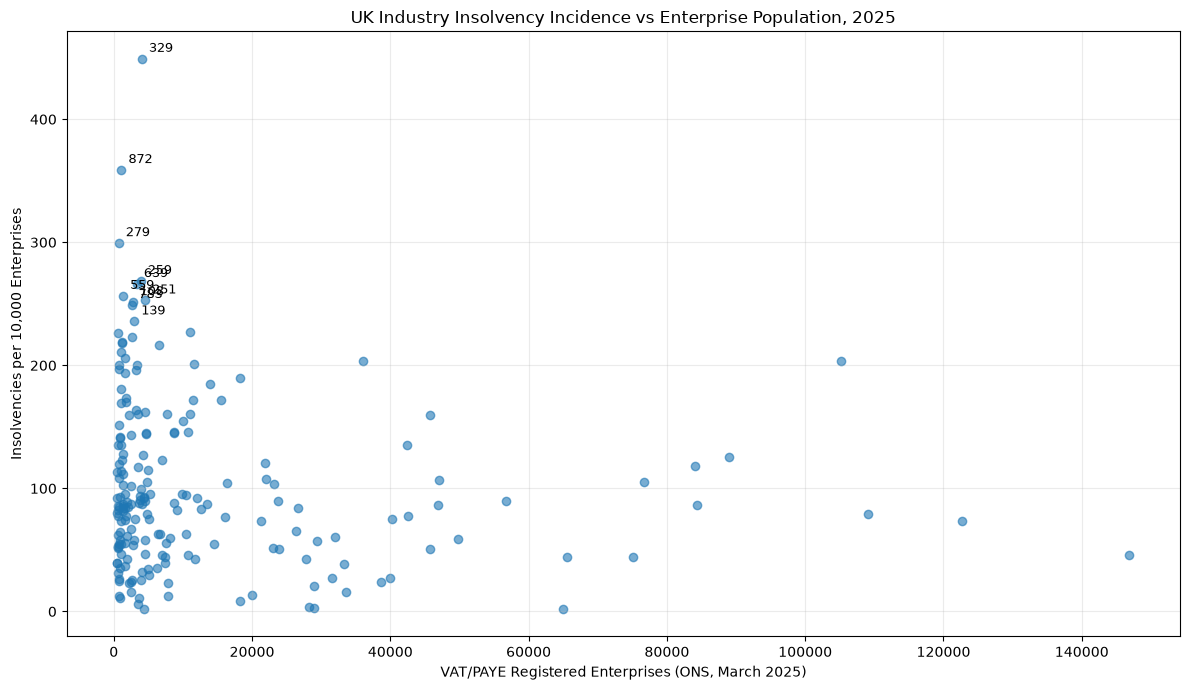

In [140]:
import matplotlib.pyplot as plt

plot_df = stable_rates_2025.copy()

fig, ax = plt.subplots(figsize=(12, 7))

ax.scatter(
    plot_df["enterprise_count"],
    plot_df["insolvencies_per_10k_enterprises"],
    alpha=0.6
)

# Label the 10 highest-rate industries
top10 = plot_df.nlargest(
    10,
    "insolvencies_per_10k_enterprises"
)

for _, row in top10.iterrows():
    ax.annotate(
        f'{row["sic07_3_digit"]}',
        (
            row["enterprise_count"],
            row["insolvencies_per_10k_enterprises"]
        ),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=9
    )

ax.set_title(
    "UK Industry Insolvency Incidence vs Enterprise Population, 2025"
)

ax.set_xlabel(
    "VAT/PAYE Registered Enterprises (ONS, March 2025)"
)

ax.set_ylabel(
    "Insolvencies per 10,000 Enterprises"
)

ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()

**Build the complete annual industry-rate panel**

In [142]:
from sqlalchemy import text
import pandas as pd

query = """
SELECT
    YEAR(month_registered) AS year,
    sic07_3_digit,
    COUNT(*) AS insolvencies
FROM fact_insolvency
WHERE include_table1b = 1
  AND sic_status = 'VALID'
  AND YEAR(month_registered) BETWEEN 2017 AND 2025
GROUP BY
    YEAR(month_registered),
    sic07_3_digit
ORDER BY
    year,
    sic07_3_digit;
"""

with engine.connect() as conn:
    annual_insolvencies = pd.read_sql(
        text(query),
        conn
    )

# Join ALL 2017–2025 ONS enterprise populations
industry_panel = enterprise_population.merge(
    annual_insolvencies,
    on=["year", "sic07_3_digit"],
    how="left"
)

industry_panel["insolvencies"] = (
    industry_panel["insolvencies"]
    .fillna(0)
    .astype(int)
)

industry_panel["insolvencies_per_10k"] = (
    industry_panel["insolvencies"]
    / industry_panel["enterprise_count"]
    * 10000
)

# Stability flag — keep the raw observations,
# but identify populations large enough for ranking
industry_panel["stable_population"] = (
    industry_panel["enterprise_count"] >= 500
)

print("Panel rows:", len(industry_panel))
print(
    "Years:",
    industry_panel["year"].min(),
    "to",
    industry_panel["year"].max()
)
print(
    "Industries:",
    industry_panel["sic07_3_digit"].nunique()
)
print(
    "Missing enterprise counts:",
    industry_panel["enterprise_count"].isna().sum()
)
print(
    "Missing insolvency counts:",
    industry_panel["insolvencies"].isna().sum()
)

display(industry_panel.head())

Panel rows: 2412
Years: 2017 to 2025
Industries: 268
Missing enterprise counts: 0
Missing insolvency counts: 0


,year,sic07_3_digit,industry_description,enterprise_count,insolvencies,insolvencies_per_10k,stable_population
0,2017,011,Growing of non-perennial crops,29915,6,2.005683,True
1,2017,012,Growing of perennial crops,1240,1,8.064516,True
2,2017,013,Plant propagation,610,0,0.000000,True
3,2017,014,Animal production,73290,12,1.637331,True
4,2017,015,Mixed farming,28770,5,1.737921,True


In [143]:
national_trend = pd.read_sql(
    """
    SELECT
        month_date,
        insolvencies,
        rolling_12m_insolvencies
    FROM vw_monthly_insolvency_trends
    ORDER BY month_date
    """,
    engine
)

national_trend["month_date"] = pd.to_datetime(
    national_trend["month_date"]
)

national_trend.tail()

,month_date,insolvencies,rolling_12m_insolvencies
123,2026-04-01,2182,23708.0
124,2026-05-01,1804,23283.0
125,2026-06-01,1935,23145.0
126,2026-07-01,2069,23034.0
127,2026-08-01,1857,22960.0


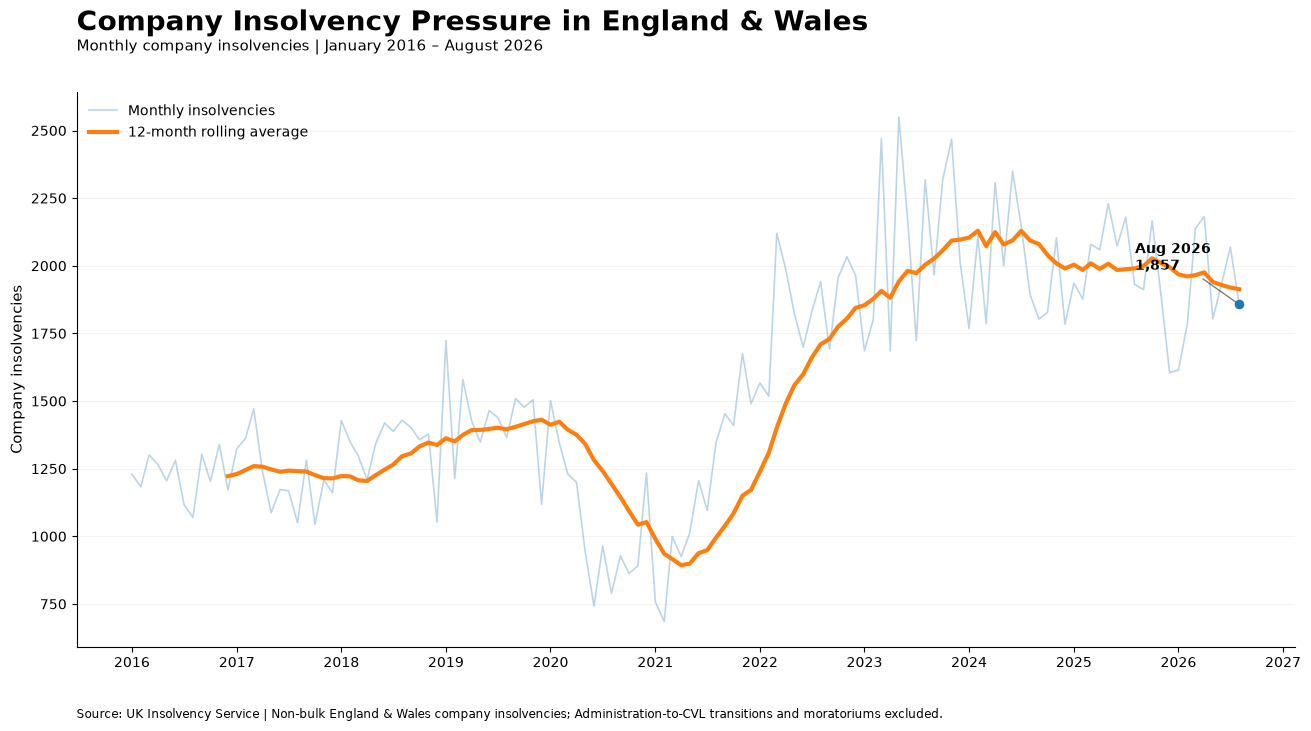

In [146]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

fig, ax = plt.subplots(figsize=(14, 7.5))

# Monthly observations
ax.plot(
    national_trend["month_date"],
    national_trend["insolvencies"],
    linewidth=1.2,
    alpha=0.30,
    label="Monthly insolvencies"
)

# 12-month rolling monthly average
ax.plot(
    national_trend["month_date"],
    national_trend["rolling_12m_insolvencies"] / 12,
    linewidth=3,
    label="12-month rolling average"
)

# ----- HEADER -----
fig.suptitle(
    "Company Insolvency Pressure in England & Wales",
    x=0.10,
    y=0.97,
    ha="left",
    fontsize=20,
    fontweight="bold"
)

fig.text(
    0.10,
    0.915,
    "Monthly company insolvencies | January 2016 – August 2026",
    ha="left",
    fontsize=11
)

# ----- AXES -----
ax.set_ylabel("Company insolvencies", fontsize=11)
ax.set_xlabel("")

ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.grid(
    axis="y",
    alpha=0.15
)

ax.legend(
    frameon=False,
    loc="upper left"
)

# ----- LATEST OBSERVATION -----
latest = national_trend.iloc[-1]

ax.scatter(
    latest["month_date"],
    latest["insolvencies"],
    s=35,
    zorder=5
)

ax.annotate(
    f'Aug 2026\n{int(latest["insolvencies"]):,}',
    xy=(
        latest["month_date"],
        latest["insolvencies"]
    ),
    xytext=(-75, 25),
    textcoords="offset points",
    fontsize=10,
    fontweight="bold",
    arrowprops=dict(
        arrowstyle="-",
        alpha=0.5
    )
)

# ----- SOURCE -----
fig.text(
    0.10,
    0.025,
    "Source: UK Insolvency Service | Non-bulk England & Wales company insolvencies; "
    "Administration-to-CVL transitions and moratoriums excluded.",
    fontsize=8.5
)

# Reserve space for header + footer
plt.subplots_adjust(
    top=0.86,
    bottom=0.12,
    left=0.10,
    right=0.97
)

plt.savefig(
    "01_uk_insolvency_trend.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [147]:
# 2025 industries with a sufficiently large enterprise population
v2 = industry_panel[
    (industry_panel["year"] == 2025) &
    (industry_panel["stable_population"])
].copy()

# Select highest insolvency-volume industries
v2 = (
    v2.nlargest(10, "insolvencies")
      .sort_values("insolvencies")
)

v2[
    [
        "sic07_3_digit",
        "industry_description",
        "enterprise_count",
        "insolvencies",
        "insolvencies_per_10k"
    ]
]

,sic07_3_digit,industry_description,enterprise_count,insolvencies,insolvencies_per_10k
2352,702,Management consultancy activities,146885,670,45.613916
2278,433,Building completion and finishing,84370,728,86.286595
2271,411,Development of building projects,45690,730,159.772379
2322,563,Beverage serving activities,36115,736,203.793438
2272,412,Construction of residential and non-residential buildings,76715,808,105.324904
2277,432,Electrical; plumbing and other construction installation activities,109045,862,79.049934
2333,620,Computer programming; consultancy and related activities,122635,901,73.470053
2411,960,Other personal service activities,83995,993,118.221323
2382,829,Business support service activities n.e.c.,89015,1116,125.372128
2320,561,Restaurants and mobile food service activities,105140,2137,203.252806


In [148]:
# Top 10 sectors by 2025 insolvency volume
rank_df = (
    industry_panel[
        (industry_panel["year"] == 2025) &
        (industry_panel["stable_population"])
    ]
    .nlargest(10, "insolvencies")
    .copy()
)

# Rank within these 10 sectors
rank_df["volume_rank"] = (
    rank_df["insolvencies"]
    .rank(method="min", ascending=False)
    .astype(int)
)

rank_df["incidence_rank"] = (
    rank_df["insolvencies_per_10k"]
    .rank(method="min", ascending=False)
    .astype(int)
)

rank_df["label"] = (
    rank_df["sic07_3_digit"] + "  " +
    rank_df["industry_description"]
)

rank_df = rank_df.sort_values("volume_rank")

display(
    rank_df[
        [
            "sic07_3_digit",
            "industry_description",
            "insolvencies",
            "insolvencies_per_10k",
            "volume_rank",
            "incidence_rank"
        ]
    ]
)

,sic07_3_digit,industry_description,insolvencies,insolvencies_per_10k,volume_rank,incidence_rank
2320,561,Restaurants and mobile food service activities,2137,203.252806,1,2
2382,829,Business support service activities n.e.c.,1116,125.372128,2,4
2411,960,Other personal service activities,993,118.221323,3,5
2333,620,Computer programming; consultancy and related activities,901,73.470053,4,9
2277,432,Electrical; plumbing and other construction installation activities,862,79.049934,5,8
2272,412,Construction of residential and non-residential buildings,808,105.324904,6,6
2322,563,Beverage serving activities,736,203.793438,7,1
2271,411,Development of building projects,730,159.772379,8,3
2278,433,Building completion and finishing,728,86.286595,9,7
2352,702,Management consultancy activities,670,45.613916,10,10


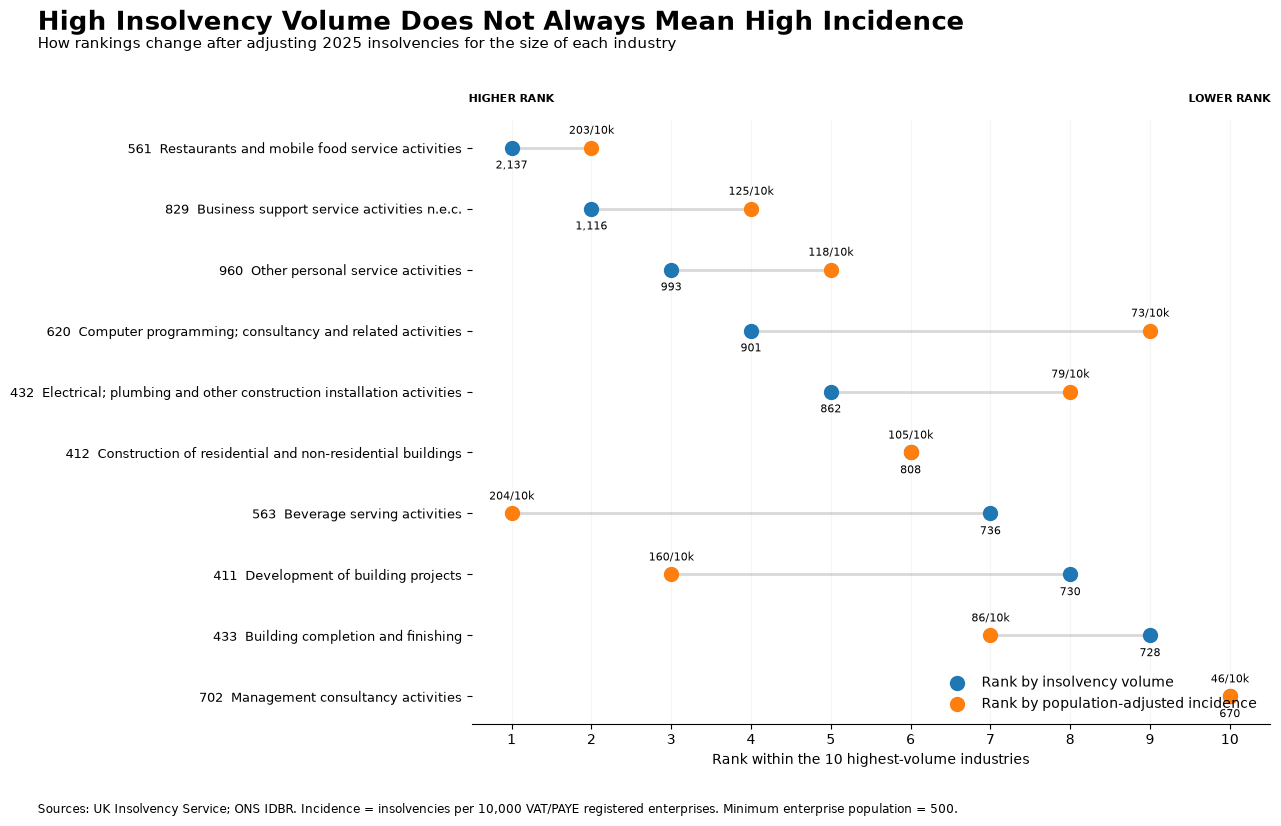

In [150]:
import matplotlib.pyplot as plt

# Keep sectors ordered by volume rank
plot_rank = rank_df.sort_values("volume_rank").reset_index(drop=True)

fig, ax = plt.subplots(figsize=(14, 8.5))

y = range(len(plot_rank))

# Neutral connectors
for i, (_, row) in enumerate(plot_rank.iterrows()):
    ax.plot(
        [row["volume_rank"], row["incidence_rank"]],
        [i, i],
        linewidth=2,
        alpha=0.30,
        color="grey",
        zorder=1
    )

# Volume rank
ax.scatter(
    plot_rank["volume_rank"],
    y,
    s=100,
    label="Rank by insolvency volume",
    zorder=3
)

# Incidence rank
ax.scatter(
    plot_rank["incidence_rank"],
    y,
    s=100,
    label="Rank by population-adjusted incidence",
    zorder=3
)

# Actual values next to the dots
for i, (_, row) in enumerate(plot_rank.iterrows()):

    ax.annotate(
        f'{int(row["insolvencies"]):,}',
        (row["volume_rank"], i),
        xytext=(0, -15),
        textcoords="offset points",
        ha="center",
        fontsize=8
    )

    ax.annotate(
        f'{row["insolvencies_per_10k"]:.0f}/10k',
        (row["incidence_rank"], i),
        xytext=(0, 10),
        textcoords="offset points",
        ha="center",
        fontsize=8
    )

# Industry labels
ax.set_yticks(list(y))

ax.set_yticklabels(
    [
        f'{code}  {name}'
        for code, name in zip(
            plot_rank["sic07_3_digit"],
            plot_rank["industry_description"]
        )
    ],
    fontsize=9
)

ax.invert_yaxis()

# Rank 1 on LEFT
ax.set_xticks(range(1, 11))
ax.set_xlim(0.5, 10.5)

ax.set_xlabel(
    "Rank within the 10 highest-volume industries",
    fontsize=10
)

# Header
fig.suptitle(
    "High Insolvency Volume Does Not Always Mean High Incidence",
    x=0.08,
    y=0.97,
    ha="left",
    fontsize=19,
    fontweight="bold"
)

fig.text(
    0.08,
    0.925,
    "How rankings change after adjusting 2025 insolvencies for the size of each industry",
    fontsize=11
)

# Legend
ax.legend(
    frameon=False,
    loc="lower right"
)

# Styling
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)

ax.grid(
    axis="x",
    alpha=0.12
)

# Helpful rank labels
ax.text(
    1,
    -0.75,
    "HIGHER RANK",
    fontsize=8,
    fontweight="bold",
    ha="center"
)

ax.text(
    10,
    -0.75,
    "LOWER RANK",
    fontsize=8,
    fontweight="bold",
    ha="center"
)

# Source
fig.text(
    0.08,
    0.025,
    "Sources: UK Insolvency Service; ONS IDBR. "
    "Incidence = insolvencies per 10,000 VAT/PAYE registered enterprises. "
    "Minimum enterprise population = 500.",
    fontsize=8.5
)

plt.subplots_adjust(
    left=0.39,
    right=0.96,
    top=0.84,
    bottom=0.13
)

plt.savefig(
    "02_volume_vs_incidence_rank_final.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [151]:
# Stable-population observations only
trend_base = industry_panel[
    industry_panel["stable_population"]
].copy()

# 2019 baseline
rate_2019 = (
    trend_base[trend_base["year"] == 2019]
    [
        [
            "sic07_3_digit",
            "industry_description",
            "enterprise_count",
            "insolvencies_per_10k"
        ]
    ]
    .rename(columns={
        "enterprise_count": "enterprises_2019",
        "insolvencies_per_10k": "rate_2019"
    })
)

# 2025 endpoint
rate_2025 = (
    trend_base[trend_base["year"] == 2025]
    [
        [
            "sic07_3_digit",
            "enterprise_count",
            "insolvencies_per_10k"
        ]
    ]
    .rename(columns={
        "enterprise_count": "enterprises_2025",
        "insolvencies_per_10k": "rate_2025"
    })
)

change_2019_2025 = rate_2019.merge(
    rate_2025,
    on="sic07_3_digit",
    how="inner"
)

change_2019_2025["absolute_rate_change"] = (
    change_2019_2025["rate_2025"]
    - change_2019_2025["rate_2019"]
)

change_2019_2025["pct_rate_change"] = (
    100 *
    change_2019_2025["absolute_rate_change"]
    / change_2019_2025["rate_2019"].replace(0, pd.NA)
)

display(
    change_2019_2025
    .sort_values(
        "absolute_rate_change",
        ascending=False
    )
    .head(15)
)

,sic07_3_digit,industry_description,enterprises_2019,rate_2019,enterprises_2025,rate_2025,absolute_rate_change,pct_rate_change
182,872,Residential care activities for mental retardation; mental health and substance abuse,740,108.108108,1115,358.744395,250.636287,231.838565
27,221,Manufacture of rubber products,550,18.181818,575,226.086957,207.905138,1143.478261
128,643,Trusts; funds and similar financial entities,1500,60.000000,1600,193.750000,133.750000,222.916667
44,279,Manufacture of other electrical equipment,695,172.661871,735,299.319728,126.657857,73.356009
125,639,Other information service activities,4130,140.435835,3345,266.068759,125.632924,89.459306
21,172,Manufacture of articles of paper and paperboard,1140,96.491228,1145,218.340611,121.849383,126.28027
15,110,Manufacture of beverages,2465,101.419878,2695,222.634508,121.214630,119.517625
10,101,Processing and preserving of meat and production of meat products,1000,90.000000,995,211.055276,121.055276,134.505863
110,559,Other accommodation,1075,139.534884,1365,256.410256,116.875373,83.760684
157,781,Activities of employment placement agencies,17635,84.491069,18220,189.352360,104.861291,124.10932


The largest increases are not all in the sectors with the largest raw insolvency counts. For example, SIC 872 rose from about 108 to 359 per 10k, while rubber products rose from about 18 to 226 per 10k. But we shouldn’t conclude from two endpoints alone that these sectors steadily deteriorated—the change could have happened in one unusual year.

So before making Visual 3, let’s use the full 2017–2025 history we built and see the trajectories of these sectors.

In [152]:
# Top 10 industries by absolute increase from 2019 to 2025
top_change_codes = (
    change_2019_2025
    .nlargest(10, "absolute_rate_change")["sic07_3_digit"]
    .tolist()
)

trajectory = (
    industry_panel[
        industry_panel["sic07_3_digit"].isin(top_change_codes)
    ]
    [
        [
            "year",
            "sic07_3_digit",
            "industry_description",
            "enterprise_count",
            "insolvencies",
            "insolvencies_per_10k"
        ]
    ]
    .sort_values(["sic07_3_digit", "year"])
)

# Pivot so we can inspect every annual rate clearly
trajectory_table = trajectory.pivot(
    index=["sic07_3_digit", "industry_description"],
    columns="year",
    values="insolvencies_per_10k"
).round(1)

display(trajectory_table)

,year,2017,2018,2019,2020,2021,2022,2023,2024,2025
sic07_3_digit,industry_description,,,,,,,,,
101,Processing and preserving of meat and production of meat products,160.0,242.4,90.0,131.3,78.8,117.1,200.0,150.0,211.1
110,Manufacture of beverages,113.9,123.6,101.4,108.1,62.3,232.8,300.4,273.4,222.6
172,Manufacture of articles of paper and paperboard,184.9,157.2,96.5,182.6,66.9,194.9,225.9,278.5,218.3
221,Manufacture of rubber products,71.4,91.7,18.2,73.4,37.0,55.0,129.6,93.5,226.1
279,Manufacture of other electrical equipment,212.8,281.7,172.7,148.6,121.6,150.7,122.4,208.3,299.3
559,Other accommodation,139.8,160.0,139.5,154.5,163.9,325.4,282.4,222.2,256.4
639,Other information service activities,165.2,166.4,140.4,119.8,143.0,181.6,219.0,216.2,266.1
643,Trusts; funds and similar financial entities,41.2,40.1,60.0,85.5,111.8,110.7,104.9,180.6,193.8
781,Activities of employment placement agencies,103.9,75.3,84.5,75.7,84.8,122.2,145.5,165.9,189.4


Emerging industry insolvency pressure, 2017–2025

Let’s use the top 10 we just investigated but visually emphasise the recent period.

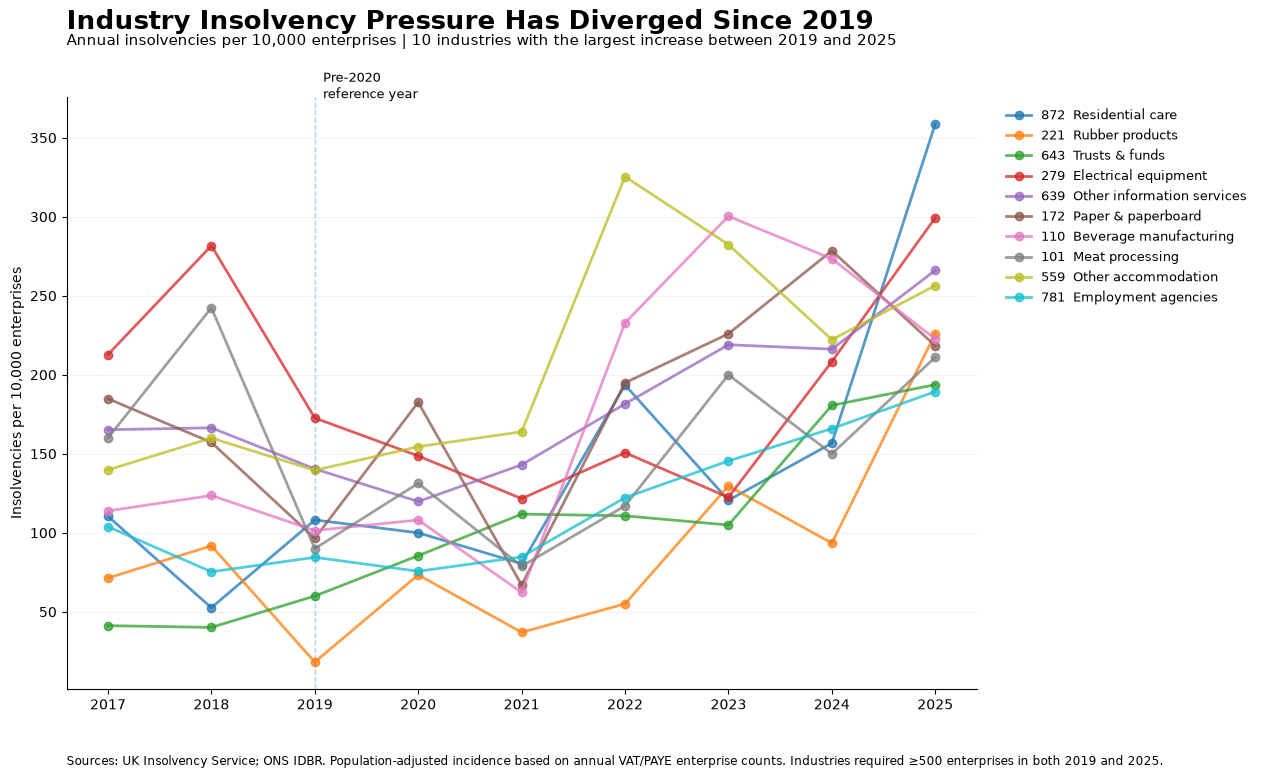

In [153]:
import matplotlib.pyplot as plt
import pandas as pd

# Shorter display names for a clean portfolio chart
short_names = {
    "101": "Meat processing",
    "110": "Beverage manufacturing",
    "172": "Paper & paperboard",
    "221": "Rubber products",
    "279": "Electrical equipment",
    "559": "Other accommodation",
    "639": "Other information services",
    "643": "Trusts & funds",
    "781": "Employment agencies",
    "872": "Residential care"
}

plot3 = trajectory.copy()

plot3["short_name"] = (
    plot3["sic07_3_digit"]
    .map(short_names)
)

fig, ax = plt.subplots(figsize=(14, 8))

# Plot each industry's full history
for code in top_change_codes:

    temp = plot3[
        plot3["sic07_3_digit"] == code
    ].sort_values("year")

    ax.plot(
        temp["year"],
        temp["insolvencies_per_10k"],
        marker="o",
        linewidth=2,
        alpha=0.75,
        label=f'{code}  {short_names[code]}'
    )

# Reference line for pre-2020 point
ax.axvline(
    2019,
    linestyle="--",
    linewidth=1,
    alpha=0.35
)

ax.text(
    2019.08,
    375,
    "Pre-2020\nreference year",
    fontsize=9
)

# Header
fig.suptitle(
    "Industry Insolvency Pressure Has Diverged Since 2019",
    x=0.08,
    y=0.97,
    ha="left",
    fontsize=19,
    fontweight="bold"
)

fig.text(
    0.08,
    0.925,
    "Annual insolvencies per 10,000 enterprises | "
    "10 industries with the largest increase between 2019 and 2025",
    fontsize=11
)

ax.set_xlabel("")
ax.set_ylabel(
    "Insolvencies per 10,000 enterprises",
    fontsize=10
)

ax.set_xticks(range(2017, 2026))

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.grid(
    axis="y",
    alpha=0.15
)

ax.legend(
    frameon=False,
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    fontsize=9
)

fig.text(
    0.08,
    0.025,
    "Sources: UK Insolvency Service; ONS IDBR. "
    "Population-adjusted incidence based on annual VAT/PAYE enterprise counts. "
    "Industries required ≥500 enterprises in both 2019 and 2025.",
    fontsize=8.5
)

plt.subplots_adjust(
    left=0.08,
    right=0.73,
    top=0.86,
    bottom=0.12
)

plt.savefig(
    "03_industry_pressure_2017_2025.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

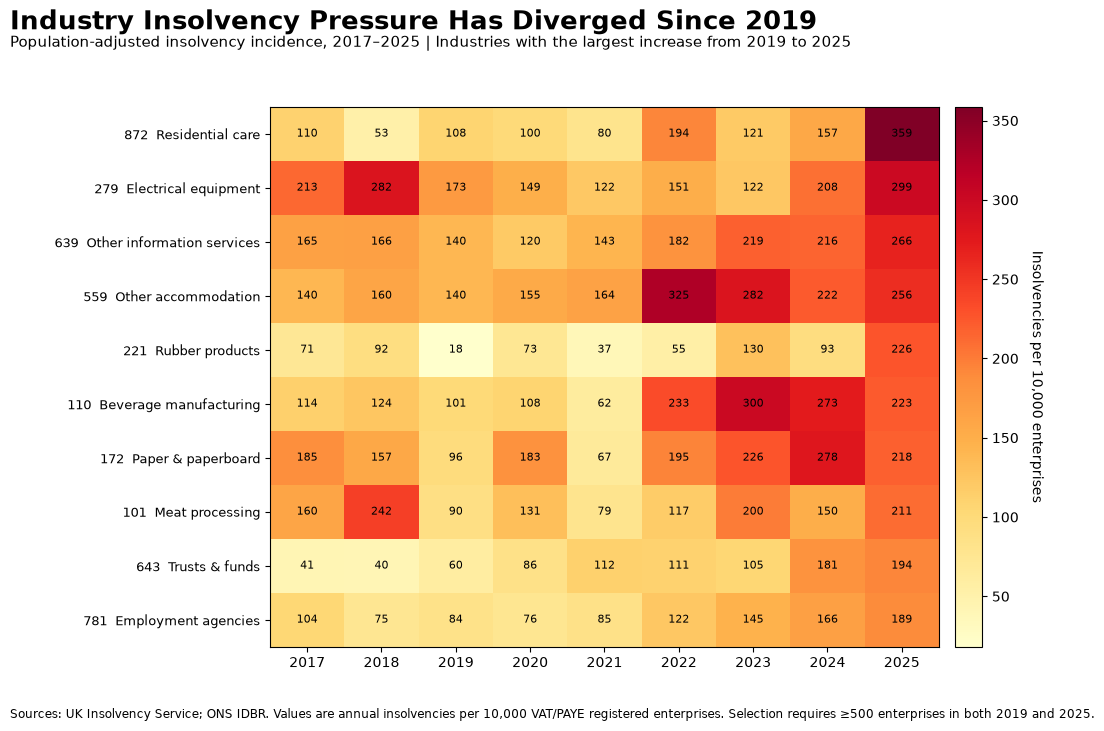

In [154]:
import matplotlib.pyplot as plt
import pandas as pd

# Prepare matrix
heatmap_df = (
    trajectory
    .assign(
        short_name=lambda x:
            x["sic07_3_digit"] + "  " +
            x["sic07_3_digit"].map(short_names)
    )
    .pivot(
        index="short_name",
        columns="year",
        values="insolvencies_per_10k"
    )
)

# Order by 2025 incidence
heatmap_df = heatmap_df.sort_values(
    2025,
    ascending=False
)

fig, ax = plt.subplots(figsize=(13, 7.5))

im = ax.imshow(
    heatmap_df.values,
    aspect="auto",
    cmap="YlOrRd"
)

# Axes
ax.set_xticks(range(len(heatmap_df.columns)))
ax.set_xticklabels(heatmap_df.columns)

ax.set_yticks(range(len(heatmap_df.index)))
ax.set_yticklabels(heatmap_df.index, fontsize=9)

ax.set_xlabel("")
ax.set_ylabel("")

# Put actual rate inside every cell
for i in range(heatmap_df.shape[0]):
    for j in range(heatmap_df.shape[1]):

        value = heatmap_df.iloc[i, j]

        ax.text(
            j,
            i,
            f"{value:.0f}",
            ha="center",
            va="center",
            fontsize=8,
            color="black"
        )

# Colour scale
cbar = fig.colorbar(
    im,
    ax=ax,
    pad=0.02
)

cbar.set_label(
    "Insolvencies per 10,000 enterprises",
    rotation=270,
    labelpad=18
)

# Header
fig.suptitle(
    "Industry Insolvency Pressure Has Diverged Since 2019",
    x=0.08,
    y=0.97,
    ha="left",
    fontsize=19,
    fontweight="bold"
)

fig.text(
    0.08,
    0.92,
    "Population-adjusted insolvency incidence, 2017–2025 | "
    "Industries with the largest increase from 2019 to 2025",
    fontsize=10.5
)

fig.text(
    0.08,
    0.025,
    "Sources: UK Insolvency Service; ONS IDBR. "
    "Values are annual insolvencies per 10,000 VAT/PAYE registered enterprises. "
    "Selection requires ≥500 enterprises in both 2019 and 2025.",
    fontsize=8.3
)

plt.subplots_adjust(
    left=0.28,
    right=0.90,
    top=0.84,
    bottom=0.12
)

plt.savefig(
    "03_industry_pressure_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 6. Forecasting: can recent patterns predict the next 3 months?

A simple historical-average baseline is benchmarked against Ridge Regression, Random Forest and Gradient Boosting models, using a proper chronological train/validation/test split so results reflect genuinely unseen future months.


In [155]:
import pandas as pd

industry_trends = pd.read_sql(
    """
    SELECT *
    FROM vw_industry_trends
    ORDER BY sic07_3_digit, month_date
    """,
    con=engine
)

print("Rows:", len(industry_trends))
print("Industries:", industry_trends["sic07_3_digit"].nunique())
print(
    "Period:",
    industry_trends["month_date"].min(),
    "to",
    industry_trends["month_date"].max()
)

industry_trends.head()

Rows: 34816
Industries: 272
Period: 2016-01-01 to 2026-08-01


,month_date,sic07_3_digit,industry_description,insolvencies,insolvencies_12m_ago,yoy_change_pct,rolling_12m_insolvencies,previous_12m_insolvencies,rolling_12m_change_pct
0,2016-01-01,011,Growing of non-perennial crops,1,NaN,NaN,NaN,NaN,NaN
1,2016-02-01,011,Growing of non-perennial crops,0,NaN,NaN,NaN,NaN,NaN
2,2016-03-01,011,Growing of non-perennial crops,0,NaN,NaN,NaN,NaN,NaN
3,2016-04-01,011,Growing of non-perennial crops,1,NaN,NaN,NaN,NaN,NaN
4,2016-05-01,011,Growing of non-perennial crops,0,NaN,NaN,NaN,NaN,NaN


In [156]:
# Make sure join keys have matching types
industry_trends["month_date"] = pd.to_datetime(
    industry_trends["month_date"]
)

industry_trends["year"] = (
    industry_trends["month_date"].dt.year
)

industry_trends["sic07_3_digit"] = (
    industry_trends["sic07_3_digit"]
    .astype(str)
    .str.zfill(3)
)

enterprise_population["sic07_3_digit"] = (
    enterprise_population["sic07_3_digit"]
    .astype(str)
    .str.zfill(3)
)

# Keep only denominator fields needed for the join
ons_denominator = enterprise_population[
    [
        "year",
        "sic07_3_digit",
        "enterprise_count"
    ]
].copy()

# Join ONS annual enterprise population onto monthly SQL panel
model_panel = industry_trends.merge(
    ons_denominator,
    on=["year", "sic07_3_digit"],
    how="left",
    validate="many_to_one"
)

# Monthly incidence using annual enterprise population denominator
model_panel["monthly_insolvencies_per_10k"] = (
    model_panel["insolvencies"]
    / model_panel["enterprise_count"]
    * 10000
)

print("Rows:", len(model_panel))
print("Industries:", model_panel["sic07_3_digit"].nunique())

print("\nEnterprise denominator available by year:")
print(
    model_panel.groupby("year")["enterprise_count"]
    .apply(lambda x: x.notna().sum())
)

display(
    model_panel[
        [
            "month_date",
            "sic07_3_digit",
            "industry_description",
            "insolvencies",
            "rolling_12m_insolvencies",
            "rolling_12m_change_pct",
            "enterprise_count",
            "monthly_insolvencies_per_10k"
        ]
    ].tail()
)

Rows: 34816
Industries: 272

Enterprise denominator available by year:
year
2016       0
2017    3216
2018    3216
2019    3216
2020    3216
2021    3216
2022    3216
2023    3216
2024    3216
2025    3216
2026       0
Name: enterprise_count, dtype: int64


,month_date,sic07_3_digit,industry_description,insolvencies,rolling_12m_insolvencies,rolling_12m_change_pct,enterprise_count,monthly_insolvencies_per_10k
34811,2026-04-01,990,Activities of extraterritorial organisations and bodies,0,3.0,NaN,NaN,NaN
34812,2026-05-01,990,Activities of extraterritorial organisations and bodies,0,3.0,NaN,NaN,NaN
34813,2026-06-01,990,Activities of extraterritorial organisations and bodies,0,3.0,NaN,NaN,NaN
34814,2026-07-01,990,Activities of extraterritorial organisations and bodies,0,3.0,NaN,NaN,NaN
34815,2026-08-01,990,Activities of extraterritorial organisations and bodies,0,2.0,100.0,NaN,NaN


In [157]:
# sort before creating future/lagged features
model_panel = (
    model_panel
    .sort_values(
        ["sic07_3_digit", "month_date"]
    )
    .reset_index(drop=True)
)

g = model_panel.groupby(
    "sic07_3_digit",
    group_keys=False
)

# Future 1, 2 and 3 month insolvencies
model_panel["future_m1"] = g["insolvencies"].shift(-1)
model_panel["future_m2"] = g["insolvencies"].shift(-2)
model_panel["future_m3"] = g["insolvencies"].shift(-3)

# Target: total insolvencies over NEXT three months
model_panel["future_3m_insolvencies"] = (
    model_panel["future_m1"]
    + model_panel["future_m2"]
    + model_panel["future_m3"]
)

# Flag rows where the complete future horizon exists
model_panel["target_available"] = (
    model_panel[
        ["future_m1", "future_m2", "future_m3"]
    ]
    .notna()
    .all(axis=1)
)

print(
    "Rows with complete 3-month future target:",
    model_panel["target_available"].sum()
)

print(
    "Rows without complete future target:",
    (~model_panel["target_available"]).sum()
)

display(
    model_panel[
        [
            "month_date",
            "sic07_3_digit",
            "insolvencies",
            "future_m1",
            "future_m2",
            "future_m3",
            "future_3m_insolvencies",
            "target_available"
        ]
    ].tail(8)
)

Rows with complete 3-month future target: 34000
Rows without complete future target: 816


,month_date,sic07_3_digit,insolvencies,future_m1,future_m2,future_m3,future_3m_insolvencies,target_available
34808,2026-01-01,990,0,0.0,0.0,0.0,0.0,True
34809,2026-02-01,990,0,0.0,0.0,0.0,0.0,True
34810,2026-03-01,990,0,0.0,0.0,0.0,0.0,True
34811,2026-04-01,990,0,0.0,0.0,0.0,0.0,True
34812,2026-05-01,990,0,0.0,0.0,0.0,0.0,True
34813,2026-06-01,990,0,0.0,0.0,NaN,NaN,False
34814,2026-07-01,990,0,0.0,NaN,NaN,NaN,False
34815,2026-08-01,990,0,NaN,NaN,NaN,NaN,False


In [158]:
# Make sure ordering is still correct
model_panel = (
    model_panel
    .sort_values(["sic07_3_digit", "month_date"])
    .reset_index(drop=True)
)

g = model_panel.groupby("sic07_3_digit")

# ---------------------------
# Recent insolvency history
# ---------------------------

model_panel["lag_1m"] = g["insolvencies"].shift(1)
model_panel["lag_3m"] = g["insolvencies"].shift(3)
model_panel["lag_6m"] = g["insolvencies"].shift(6)
model_panel["lag_12m"] = g["insolvencies"].shift(12)


# ---------------------------
# Historical rolling features
# Exclude current month to make
# them strictly backward-looking
# ---------------------------

model_panel["previous_3m_total"] = (
    g["insolvencies"]
    .transform(
        lambda s: s.shift(1).rolling(3).sum()
    )
)

model_panel["previous_6m_total"] = (
    g["insolvencies"]
    .transform(
        lambda s: s.shift(1).rolling(6).sum()
    )
)

model_panel["previous_12m_total"] = (
    g["insolvencies"]
    .transform(
        lambda s: s.shift(1).rolling(12).sum()
    )
)


# ---------------------------
# Short-term momentum
# previous 3 months versus
# preceding 3 months
# ---------------------------

model_panel["preceding_3m_total"] = (
    g["insolvencies"]
    .transform(
        lambda s: s.shift(4).rolling(3).sum()
    )
)

model_panel["momentum_3m_pct"] = (
    100
    * (
        model_panel["previous_3m_total"]
        - model_panel["preceding_3m_total"]
    )
    / model_panel["preceding_3m_total"].replace(0, pd.NA)
)


# ---------------------------
# Population-adjusted history
# ---------------------------

model_panel["previous_12m_per_10k"] = (
    model_panel["previous_12m_total"]
    / model_panel["enterprise_count"]
    * 10000
)


# Calendar features
model_panel["month_number"] = model_panel["month_date"].dt.month
model_panel["quarter"] = model_panel["month_date"].dt.quarter


# QA
feature_cols = [
    "lag_1m",
    "lag_3m",
    "lag_6m",
    "lag_12m",
    "previous_3m_total",
    "previous_6m_total",
    "previous_12m_total",
    "preceding_3m_total",
    "momentum_3m_pct",
    "previous_12m_per_10k"
]

print("Feature missing values:")
print(model_panel[feature_cols].isna().sum())

display(
    model_panel[
        [
            "month_date",
            "sic07_3_digit",
            "insolvencies",
            "lag_1m",
            "previous_3m_total",
            "preceding_3m_total",
            "momentum_3m_pct",
            "previous_12m_total",
            "previous_12m_per_10k",
            "future_3m_insolvencies"
        ]
    ].tail(12)
)

Feature missing values:
lag_1m                   272
lag_3m                   816
lag_6m                  1632
lag_12m                 3264
previous_3m_total        816
previous_6m_total       1632
previous_12m_total      3264
preceding_3m_total      1632
momentum_3m_pct         9771
previous_12m_per_10k    6237
dtype: int64


,month_date,sic07_3_digit,insolvencies,lag_1m,previous_3m_total,preceding_3m_total,momentum_3m_pct,previous_12m_total,previous_12m_per_10k,future_3m_insolvencies
34804,2025-09-01,990,0,1.0,1.0,0.0,<NA>,1.0,NaN,2.0
34805,2025-10-01,990,1,0.0,1.0,0.0,<NA>,1.0,NaN,1.0
34806,2025-11-01,990,1,1.0,2.0,0.0,<NA>,2.0,NaN,0.0
34807,2025-12-01,990,0,1.0,2.0,1.0,100.0,3.0,NaN,0.0
34808,2026-01-01,990,0,0.0,2.0,1.0,100.0,3.0,NaN,0.0
34809,2026-02-01,990,0,0.0,1.0,2.0,-50.0,3.0,NaN,0.0
34810,2026-03-01,990,0,0.0,0.0,2.0,-100.0,3.0,NaN,0.0
34811,2026-04-01,990,0,0.0,0.0,2.0,-100.0,3.0,NaN,0.0
34812,2026-05-01,990,0,0.0,0.0,1.0,-100.0,3.0,NaN,0.0
34813,2026-06-01,990,0,0.0,0.0,0.0,<NA>,3.0,NaN,NaN


In [159]:
# Features for our first baseline model
feature_cols = [
    "lag_1m",
    "lag_3m",
    "lag_6m",
    "lag_12m",
    "previous_3m_total",
    "previous_6m_total",
    "previous_12m_total",
    "preceding_3m_total",
    "month_number",
    "quarter"
]

target_col = "future_3m_insolvencies"

# Keep rows where:
# 1. future target is actually observed
# 2. historical features are available
model_data = model_panel[
    model_panel["target_available"]
].copy()

model_data = model_data.dropna(
    subset=feature_cols + [target_col]
)

# Chronological split
train = model_data[
    model_data["month_date"] < "2023-01-01"
].copy()

validation = model_data[
    (model_data["month_date"] >= "2023-01-01") &
    (model_data["month_date"] < "2025-01-01")
].copy()

test = model_data[
    model_data["month_date"] >= "2025-01-01"
].copy()

print("TRAIN")
print(
    len(train),
    train["month_date"].min(),
    "to",
    train["month_date"].max()
)

print("\nVALIDATION")
print(
    len(validation),
    validation["month_date"].min(),
    "to",
    validation["month_date"].max()
)

print("\nTEST")
print(
    len(test),
    test["month_date"].min(),
    "to",
    test["month_date"].max()
)

print("\nIndustries:")
print(
    "Train:", train["sic07_3_digit"].nunique(),
    "| Validation:", validation["sic07_3_digit"].nunique(),
    "| Test:", test["sic07_3_digit"].nunique()
)

print("\nTarget summary:")
print(
    model_data[target_col].describe()
)

TRAIN
19584 2017-01-01 00:00:00 to 2022-12-01 00:00:00

VALIDATION
6528 2023-01-01 00:00:00 to 2024-12-01 00:00:00

TEST
4624 2025-01-01 00:00:00 to 2026-05-01 00:00:00

Industries:
Train: 272 | Validation: 272 | Test: 272

Target summary:
count    30736.000000
mean        17.323269
std         44.382922
min          0.000000
25%          1.000000
50%          3.000000
75%         14.000000
max        681.000000
Name: future_3m_insolvencies, dtype: float64


A sensible baseline is:

Next 3 months ≈ previous 3 months.

That is commercially interpretable and surprisingly difficult to beat in many time-series problems.

In [161]:
import numpy as np
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

def evaluate_predictions(y_true, y_pred, name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    print(name)
    print(f"MAE:  {mae:.3f}")
    print(f"RMSE: {rmse:.3f}")
    print(f"R²:   {r2:.3f}")

    return {
        "model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    }


# -----------------------------------
# Naive persistence baseline
# Future 3 months = previous 3 months
# -----------------------------------

validation_baseline_pred = validation["previous_3m_total"]
test_baseline_pred = test["previous_3m_total"]

baseline_validation = evaluate_predictions(
    validation[target_col],
    validation_baseline_pred,
    "Naive baseline — Validation"
)

print()

baseline_test = evaluate_predictions(
    test[target_col],
    test_baseline_pred,
    "Naive baseline — Test"
)

Naive baseline — Validation
MAE:  4.376
RMSE: 9.242
R²:   0.973

Naive baseline — Test
MAE:  4.543
RMSE: 10.733
R²:   0.957


In [162]:
validation_12m_pred = (
    validation["previous_12m_total"] / 4
)

test_12m_pred = (
    test["previous_12m_total"] / 4
)

baseline12_validation = evaluate_predictions(
    validation[target_col],
    validation_12m_pred,
    "12-month average baseline — Validation"
)

print()

baseline12_test = evaluate_predictions(
    test[target_col],
    test_12m_pred,
    "12-month average baseline — Test"
)

12-month average baseline — Validation
MAE:  3.709
RMSE: 9.179
R²:   0.974

12-month average baseline — Test
MAE:  3.556
RMSE: 8.617
R²:   0.973


In [163]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge

X_train = train[feature_cols]
y_train = train[target_col]

X_val = validation[feature_cols]
y_val = validation[target_col]

X_test = test[feature_cols]
y_test = test[target_col]


ridge_model = Pipeline([
    ("scaler", StandardScaler()),
    ("ridge", Ridge(alpha=1.0))
])

ridge_model.fit(X_train, y_train)


# Predictions
ridge_val_pred = ridge_model.predict(X_val)
ridge_test_pred = ridge_model.predict(X_test)

# Insolvency counts cannot be negative
ridge_val_pred = np.clip(ridge_val_pred, 0, None)
ridge_test_pred = np.clip(ridge_test_pred, 0, None)


ridge_validation = evaluate_predictions(
    y_val,
    ridge_val_pred,
    "Ridge regression — Validation"
)

print()

ridge_test = evaluate_predictions(
    y_test,
    ridge_test_pred,
    "Ridge regression — Test"
)

Ridge regression — Validation
MAE:  4.151
RMSE: 8.811
R²:   0.976

Ridge regression — Test
MAE:  4.430
RMSE: 10.428
R²:   0.960


In [164]:
from sklearn.ensemble import HistGradientBoostingRegressor

hgb_model = HistGradientBoostingRegressor(
    loss="poisson",
    learning_rate=0.05,
    max_iter=300,
    max_leaf_nodes=15,
    min_samples_leaf=30,
    l2_regularization=1.0,
    random_state=42
)

hgb_model.fit(X_train, y_train)

# Validation predictions
hgb_val_pred = hgb_model.predict(X_val)
hgb_val_pred = np.clip(hgb_val_pred, 0, None)

hgb_validation = evaluate_predictions(
    y_val,
    hgb_val_pred,
    "Poisson Gradient Boosting — Validation"
)

print()

# Test predictions — evaluation only
hgb_test_pred = hgb_model.predict(X_test)
hgb_test_pred = np.clip(hgb_test_pred, 0, None)

hgb_test = evaluate_predictions(
    y_test,
    hgb_test_pred,
    "Poisson Gradient Boosting — Test"
)

Poisson Gradient Boosting — Validation
MAE:  4.866
RMSE: 15.604
R²:   0.924

Poisson Gradient Boosting — Test
MAE:  4.693
RMSE: 13.601
R²:   0.932


In [165]:
baseline_errors = test[
    [
        "month_date",
        "sic07_3_digit",
        "industry_description",
        "previous_3m_total",
        "previous_12m_total",
        "future_3m_insolvencies"
    ]
].copy()

baseline_errors["prediction"] = (
    baseline_errors["previous_12m_total"] / 4
)

baseline_errors["error"] = (
    baseline_errors["future_3m_insolvencies"]
    - baseline_errors["prediction"]
)

baseline_errors["absolute_error"] = (
    baseline_errors["error"].abs()
)

display(
    baseline_errors
    .sort_values("absolute_error", ascending=False)
    .head(20)
)

,month_date,sic07_3_digit,industry_description,previous_3m_total,previous_12m_total,future_3m_insolvencies,prediction,error,absolute_error
25977,2026-02-01,681,Buying and selling of own real estate,55.0,257.0,242.0,64.25,177.75,177.75
25976,2026-01-01,681,Buying and selling of own real estate,57.0,251.0,238.0,62.75,175.25,175.25
25978,2026-03-01,681,Buying and selling of own real estate,51.0,258.0,188.0,64.50,123.50,123.50
25975,2025-12-01,681,Buying and selling of own real estate,65.0,249.0,177.0,62.25,114.75,114.75
22646,2025-11-01,561,Restaurants and mobile food service activities,543.0,2192.0,440.0,548.00,-108.00,108.00
22645,2025-10-01,561,Restaurants and mobile food service activities,547.0,2167.0,450.0,541.75,-91.75,91.75
30581,2025-10-01,829,Business support service activities n.e.c,270.0,1161.0,212.0,290.25,-78.25,78.25
34294,2025-11-01,960,Other personal service activities,244.0,1009.0,178.0,252.25,-74.25,74.25
30580,2025-09-01,829,Business support service activities n.e.c,279.0,1135.0,219.0,283.75,-64.75,64.75
34293,2025-10-01,960,Other personal service activities,260.0,1007.0,188.0,251.75,-63.75,63.75


In [166]:
# ---------------------------------------
# Sensitivity analysis:
# How much does SIC 681 affect test error?
# ---------------------------------------

test_diagnostic = test.copy()

test_diagnostic["baseline_prediction"] = (
    test_diagnostic["previous_12m_total"] / 4
)

test_without_681 = test_diagnostic[
    test_diagnostic["sic07_3_digit"] != "681"
].copy()

print("FULL TEST SET")
evaluate_predictions(
    test_diagnostic[target_col],
    test_diagnostic["baseline_prediction"],
    "12-month baseline — Full test"
)

print("\nTEST EXCLUDING SIC 681")
evaluate_predictions(
    test_without_681[target_col],
    test_without_681["baseline_prediction"],
    "12-month baseline — Excluding SIC 681"
)

print("\nSIC 681 ONLY")
evaluate_predictions(
    test_diagnostic.loc[
        test_diagnostic["sic07_3_digit"] == "681",
        target_col
    ],
    test_diagnostic.loc[
        test_diagnostic["sic07_3_digit"] == "681",
        "baseline_prediction"
    ],
    "12-month baseline — SIC 681 only"
)

FULL TEST SET
12-month baseline — Full test
MAE:  3.556
RMSE: 8.617
R²:   0.973

TEST EXCLUDING SIC 681
12-month baseline — Excluding SIC 681
MAE:  3.391
RMSE: 7.325
R²:   0.980

SIC 681 ONLY
12-month baseline — SIC 681 only
MAE:  48.368
RMSE: 75.201
R²:   -0.399


{'model': '12-month baseline — SIC 681 only',
 'MAE': 48.36764705882353,
 'RMSE': np.float64(75.20137181946491),
 'R2': -0.39903937105270826}

In [167]:
# Historical concentration feature
# Uses ONLY months before the prediction month

def previous_6m_peak_share(series):
    shifted = series.shift(1)

    rolling_sum = shifted.rolling(6).sum()
    rolling_max = shifted.rolling(6).max()

    return rolling_max / rolling_sum.replace(0, np.nan)


model_panel["previous_6m_peak_share"] = (
    model_panel
    .groupby("sic07_3_digit")["insolvencies"]
    .transform(previous_6m_peak_share)
)

# Also measure recent level relative to longer history
model_panel["recent_vs_12m_ratio"] = (
    (model_panel["previous_3m_total"] / 3)
    /
    (model_panel["previous_12m_total"] / 12)
).replace([np.inf, -np.inf], np.nan)


# Inspect SIC 681 around the unusual period
display(
    model_panel.loc[
        (model_panel["sic07_3_digit"] == "681") &
        (model_panel["month_date"] >= "2025-09-01"),
        [
            "month_date",
            "insolvencies",
            "previous_3m_total",
            "previous_12m_total",
            "previous_6m_peak_share",
            "recent_vs_12m_ratio",
            "future_3m_insolvencies"
        ]
    ]
)

,month_date,insolvencies,previous_3m_total,previous_12m_total,previous_6m_peak_share,recent_vs_12m_ratio,future_3m_insolvencies
25972,2025-09-01,23,77.0,233.0,0.260563,1.321888,57.0
25973,2025-10-01,22,78.0,239.0,0.245033,1.305439,55.0
25974,2025-11-01,20,76.0,249.0,0.232704,1.220884,51.0
25975,2025-12-01,15,65.0,249.0,0.218310,1.044177,177.0
25976,2026-01-01,20,57.0,251.0,0.229630,0.908367,238.0
25977,2026-02-01,16,55.0,257.0,0.236641,0.856031,242.0
25978,2026-03-01,141,51.0,258.0,0.198276,0.790698,188.0
25979,2026-04-01,81,177.0,385.0,0.602564,1.838961,130.0
25980,2026-05-01,20,238.0,452.0,0.481229,2.106195,138.0
25981,2026-06-01,87,242.0,435.0,0.481229,2.225287,NaN


In [168]:
enhanced_features = [
    "lag_1m",
    "lag_3m",
    "lag_6m",
    "lag_12m",
    "previous_3m_total",
    "previous_6m_total",
    "previous_12m_total",
    "preceding_3m_total",
    "previous_6m_peak_share",
    "recent_vs_12m_ratio",
    "month_number",
    "quarter"
]

enhanced_data = model_panel[
    model_panel["target_available"]
].copy()

enhanced_data = enhanced_data.replace(
    [np.inf, -np.inf],
    np.nan
)

enhanced_data = enhanced_data.dropna(
    subset=enhanced_features + [target_col]
)

enhanced_train = enhanced_data[
    enhanced_data["month_date"] < "2023-01-01"
].copy()

enhanced_validation = enhanced_data[
    (enhanced_data["month_date"] >= "2023-01-01") &
    (enhanced_data["month_date"] < "2025-01-01")
].copy()

enhanced_test = enhanced_data[
    enhanced_data["month_date"] >= "2025-01-01"
].copy()

print("Enhanced modelling rows:", len(enhanced_data))

print(
    "Train:", len(enhanced_train),
    "| Validation:", len(enhanced_validation),
    "| Test:", len(enhanced_test)
)

print(
    "Period:",
    enhanced_data["month_date"].min(),
    "to",
    enhanced_data["month_date"].max()
)

Enhanced modelling rows: 26022
Train: 16238 | Validation: 5732 | Test: 4052
Period: 2017-01-01 00:00:00 to 2026-05-01 00:00:00


In [169]:
# Robust short-term acceleration feature
# Does not divide by zero

model_panel["recent_vs_12m_diff"] = (
    model_panel["previous_3m_total"] / 3
    - model_panel["previous_12m_total"] / 12
)

enhanced_features = [
    "lag_1m",
    "lag_3m",
    "lag_6m",
    "lag_12m",
    "previous_3m_total",
    "previous_6m_total",
    "previous_12m_total",
    "preceding_3m_total",
    "previous_6m_peak_share",
    "recent_vs_12m_diff",
    "month_number",
    "quarter"
]

enhanced_data = model_panel[
    model_panel["target_available"]
].copy()

enhanced_data = enhanced_data.replace(
    [np.inf, -np.inf],
    np.nan
)

enhanced_data = enhanced_data.dropna(
    subset=enhanced_features + [target_col]
)

enhanced_train = enhanced_data[
    enhanced_data["month_date"] < "2023-01-01"
].copy()

enhanced_validation = enhanced_data[
    (enhanced_data["month_date"] >= "2023-01-01") &
    (enhanced_data["month_date"] < "2025-01-01")
].copy()

enhanced_test = enhanced_data[
    enhanced_data["month_date"] >= "2025-01-01"
].copy()

print("Enhanced modelling rows:", len(enhanced_data))
print(
    "Train:", len(enhanced_train),
    "| Validation:", len(enhanced_validation),
    "| Test:", len(enhanced_test)
)

print("\nMissing values:")
print(
    model_panel[
        ["previous_6m_peak_share", "recent_vs_12m_diff"]
    ].isna().sum()
)

Enhanced modelling rows: 26022
Train: 16238 | Validation: 5732 | Test: 4052

Missing values:
previous_6m_peak_share    6704
recent_vs_12m_diff        3264
dtype: int64


recent_vs_12m_diff has 3,264 missing values, which is expected: 272 industries × the first 12 months = 3,264. There isn’t enough historical data yet to calculate a previous-12-month feature.

previous_6m_peak_share has more missing values because, in addition to the initial six-month history, some low-volume industries have zero insolvencies throughout the entire previous six months. In those cases the calculation is effectively 0 / 0.

But conceptually, if an industry had no insolvencies at all during the previous six months, its peak-month concentration should be 0, not missing.

Fix only the zero-activity concentration cases

We should not blindly fillna(0) because that would also incorrectly fill the first months where six months of history don’t exist.

In [171]:
# Identify whether a COMPLETE previous 6-month history exists
model_panel["previous_6m_count"] = (
    model_panel
    .groupby("sic07_3_digit")["insolvencies"]
    .transform(
        lambda s: s.shift(1).rolling(6).count()
    )
)

# If we have all 6 historical months and their total is zero,
# concentration is logically zero rather than missing.
zero_activity_mask = (
    (model_panel["previous_6m_count"] == 6) &
    (model_panel["previous_6m_total"] == 0)
)

model_panel.loc[
    zero_activity_mask,
    "previous_6m_peak_share"
] = 0.0


print("Remaining missing values:")
print(
    model_panel[
        [
            "previous_6m_peak_share",
            "recent_vs_12m_diff"
        ]
    ].isna().sum()
)

Remaining missing values:
previous_6m_peak_share    1632
recent_vs_12m_diff        3264
dtype: int64


In [172]:
enhanced_data = model_panel[
    model_panel["target_available"]
].copy()

enhanced_data = enhanced_data.dropna(
    subset=enhanced_features + [target_col]
)

enhanced_train = enhanced_data[
    enhanced_data["month_date"] < "2023-01-01"
].copy()

enhanced_validation = enhanced_data[
    (enhanced_data["month_date"] >= "2023-01-01") &
    (enhanced_data["month_date"] < "2025-01-01")
].copy()

enhanced_test = enhanced_data[
    enhanced_data["month_date"] >= "2025-01-01"
].copy()

print("Enhanced modelling rows:", len(enhanced_data))

print(
    "Train:", len(enhanced_train),
    "| Validation:", len(enhanced_validation),
    "| Test:", len(enhanced_test)
)

print(
    "Industries:",
    enhanced_train["sic07_3_digit"].nunique(),
    enhanced_validation["sic07_3_digit"].nunique(),
    enhanced_test["sic07_3_digit"].nunique()
)

Enhanced modelling rows: 30736
Train: 19584 | Validation: 6528 | Test: 4624
Industries: 272 272 272


In [173]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge

# Enhanced feature matrices
X_train_enh = enhanced_train[enhanced_features]
y_train_enh = enhanced_train[target_col]

X_val_enh = enhanced_validation[enhanced_features]
y_val_enh = enhanced_validation[target_col]

X_test_enh = enhanced_test[enhanced_features]
y_test_enh = enhanced_test[target_col]


enhanced_ridge = Pipeline([
    ("scaler", StandardScaler()),
    ("ridge", Ridge(alpha=1.0))
])

enhanced_ridge.fit(X_train_enh, y_train_enh)


# Predictions
enh_ridge_val_pred = enhanced_ridge.predict(X_val_enh)
enh_ridge_test_pred = enhanced_ridge.predict(X_test_enh)

# Counts cannot be negative
enh_ridge_val_pred = np.clip(enh_ridge_val_pred, 0, None)
enh_ridge_test_pred = np.clip(enh_ridge_test_pred, 0, None)


print("ENHANCED RIDGE")
print()

enh_ridge_validation = evaluate_predictions(
    y_val_enh,
    enh_ridge_val_pred,
    "Enhanced Ridge — Validation"
)

print()

enh_ridge_test = evaluate_predictions(
    y_test_enh,
    enh_ridge_test_pred,
    "Enhanced Ridge — Test"
)

ENHANCED RIDGE

Enhanced Ridge — Validation
MAE:  4.154
RMSE: 8.810
R²:   0.976

Enhanced Ridge — Test
MAE:  4.436
RMSE: 10.434
R²:   0.960


In [174]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=12,
    min_samples_leaf=5,
    max_features=0.8,
    n_jobs=-1,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_val_pred = rf_model.predict(X_val)
rf_test_pred = rf_model.predict(X_test)

rf_validation = evaluate_predictions(
    y_val,
    rf_val_pred,
    "Random Forest — Validation"
)

print()

rf_test = evaluate_predictions(
    y_test,
    rf_test_pred,
    "Random Forest — Test"
)

Random Forest — Validation
MAE:  4.427
RMSE: 11.605
R²:   0.958

Random Forest — Test
MAE:  4.431
RMSE: 11.069
R²:   0.955


In [175]:
# Create previous-year ONS enterprise population
ons_lagged = enterprise_population[
    ["year", "sic07_3_digit", "enterprise_count"]
].copy()

ons_lagged["year"] = ons_lagged["year"] + 1

ons_lagged = ons_lagged.rename(
    columns={"enterprise_count": "previous_year_enterprises"}
)

# Remove the current-year enterprise count from the modelling panel
# and merge the lagged denominator
model_panel = model_panel.drop(
    columns=["previous_year_enterprises"],
    errors="ignore"
)

model_panel = model_panel.merge(
    ons_lagged,
    on=["year", "sic07_3_digit"],
    how="left",
    validate="many_to_one"
)

print(
    model_panel.groupby("year")[
        "previous_year_enterprises"
    ].count()
)

year
2016       0
2017       0
2018    3216
2019    3216
2020    3216
2021    3216
2022    3216
2023    3216
2024    3216
2025    3216
2026    2144
Name: previous_year_enterprises, dtype: int64


Next: create population-aware features

We don’t need another huge feature set. Add just two interpretable features:

1. Previous-year enterprise population — industry size.
2. Previous 12-month insolvencies per 10,000 previous-year enterprises — historical pressure adjusted for industry size.

In [176]:
model_panel["lagged_12m_incidence_per_10k"] = (
    model_panel["previous_12m_total"]
    / model_panel["previous_year_enterprises"]
    * 10000
)

population_features = [
    "lag_1m",
    "lag_3m",
    "lag_6m",
    "lag_12m",
    "previous_3m_total",
    "previous_6m_total",
    "previous_12m_total",
    "preceding_3m_total",
    "month_number",
    "quarter",
    "previous_year_enterprises",
    "lagged_12m_incidence_per_10k"
]

population_data = model_panel[
    model_panel["target_available"]
].copy()

population_data = population_data.dropna(
    subset=population_features + [target_col]
)

population_train = population_data[
    population_data["month_date"] < "2023-01-01"
].copy()

population_validation = population_data[
    (population_data["month_date"] >= "2023-01-01") &
    (population_data["month_date"] < "2025-01-01")
].copy()

population_test = population_data[
    population_data["month_date"] >= "2025-01-01"
].copy()

print("Population-aware rows:", len(population_data))

print(
    "Train:", len(population_train),
    "| Validation:", len(population_validation),
    "| Test:", len(population_test)
)

print(
    "Industries:",
    population_train["sic07_3_digit"].nunique(),
    population_validation["sic07_3_digit"].nunique(),
    population_test["sic07_3_digit"].nunique()
)

print(
    "\nPeriod:",
    population_data["month_date"].min(),
    "to",
    population_data["month_date"].max()
)

Population-aware rows: 26724
Train: 15863 | Validation: 6357 | Test: 4504
Industries: 266 266 266

Period: 2018-01-01 00:00:00 to 2026-05-01 00:00:00


In [177]:
# Matched-sample baseline for the population-aware model
# Future 3 months ≈ previous 12 months / 4

pop_val_baseline_pred = (
    population_validation["previous_12m_total"] / 4
)

pop_test_baseline_pred = (
    population_test["previous_12m_total"] / 4
)

print("POPULATION-MATCHED BASELINE")
print()

pop_baseline_validation = evaluate_predictions(
    population_validation[target_col],
    pop_val_baseline_pred,
    "12-month baseline — Population validation sample"
)

print()

pop_baseline_test = evaluate_predictions(
    population_test[target_col],
    pop_test_baseline_pred,
    "12-month baseline — Population test sample"
)

POPULATION-MATCHED BASELINE

12-month baseline — Population validation sample
MAE:  3.799
RMSE: 9.301
R²:   0.973

12-month baseline — Population test sample
MAE:  3.639
RMSE: 8.730
R²:   0.972


In [180]:
# Check every population feature for NaN / +inf / -inf

for col in population_features:
    values = population_data[col]

    print(
        col,
        "| NaN:", values.isna().sum(),
        "| +inf:", np.isposinf(values).sum(),
        "| -inf:", np.isneginf(values).sum()
    )

lag_1m | NaN: 0 | +inf: 0 | -inf: 0
lag_3m | NaN: 0 | +inf: 0 | -inf: 0
lag_6m | NaN: 0 | +inf: 0 | -inf: 0
lag_12m | NaN: 0 | +inf: 0 | -inf: 0
previous_3m_total | NaN: 0 | +inf: 0 | -inf: 0
previous_6m_total | NaN: 0 | +inf: 0 | -inf: 0
previous_12m_total | NaN: 0 | +inf: 0 | -inf: 0
preceding_3m_total | NaN: 0 | +inf: 0 | -inf: 0
month_number | NaN: 0 | +inf: 0 | -inf: 0
quarter | NaN: 0 | +inf: 0 | -inf: 0
previous_year_enterprises | NaN: 0 | +inf: 0 | -inf: 0
lagged_12m_incidence_per_10k | NaN: 0 | +inf: 60 | -inf: 0


In [181]:
# Show the actual problematic observations

problem_mask = np.isinf(
    population_data[population_features]
).any(axis=1)

display(
    population_data.loc[
        problem_mask,
        [
            "month_date",
            "sic07_3_digit",
            "industry_description",
            "previous_year_enterprises",
            "previous_12m_total",
            "lagged_12m_incidence_per_10k"
        ]
    ].head(30)
)

print("Rows containing infinity:", problem_mask.sum())


,month_date,sic07_3_digit,industry_description,previous_year_enterprises,previous_12m_total,lagged_12m_incidence_per_10k
2223,2019-12-01,071,Mining of iron ores,0.0,1.0,inf
2224,2020-01-01,071,Mining of iron ores,0.0,1.0,inf
2225,2020-02-01,071,Mining of iron ores,0.0,1.0,inf
2226,2020-03-01,071,Mining of iron ores,0.0,1.0,inf
2227,2020-04-01,071,Mining of iron ores,0.0,1.0,inf
2228,2020-05-01,071,Mining of iron ores,0.0,1.0,inf
2229,2020-06-01,071,Mining of iron ores,0.0,1.0,inf
2230,2020-07-01,071,Mining of iron ores,0.0,1.0,inf
2231,2020-08-01,071,Mining of iron ores,0.0,1.0,inf
2232,2020-09-01,071,Mining of iron ores,0.0,1.0,inf


Rows containing infinity: 60


In [182]:
# Zero enterprise population cannot be used as an incidence denominator
model_panel["lagged_12m_incidence_per_10k"] = np.where(
    model_panel["previous_year_enterprises"] > 0,
    (
        model_panel["previous_12m_total"]
        / model_panel["previous_year_enterprises"]
        * 10000
    ),
    np.nan
)

In [183]:
population_data = model_panel[
    model_panel["target_available"]
].copy()

# Defensive check: convert any remaining infinities to missing
population_data[population_features] = (
    population_data[population_features]
    .replace([np.inf, -np.inf], np.nan)
)

population_data = population_data.dropna(
    subset=population_features + [target_col]
)

population_train = population_data[
    population_data["month_date"] < "2023-01-01"
].copy()

population_validation = population_data[
    (population_data["month_date"] >= "2023-01-01") &
    (population_data["month_date"] < "2025-01-01")
].copy()

population_test = population_data[
    population_data["month_date"] >= "2025-01-01"
].copy()


print("Population-aware rows:", len(population_data))

print(
    "Train:", len(population_train),
    "| Validation:", len(population_validation),
    "| Test:", len(population_test)
)

print(
    "Industries:",
    population_train["sic07_3_digit"].nunique(),
    population_validation["sic07_3_digit"].nunique(),
    population_test["sic07_3_digit"].nunique()
)

print(
    "Remaining infinities:",
    np.isinf(
        population_data[population_features].to_numpy()
    ).sum()
)

Population-aware rows: 26664
Train: 15840 | Validation: 6336 | Test: 4488
Industries: 264 264 264
Remaining infinities: 0


In [184]:
# Final matched-sample baseline
# for the cleaned population-aware dataset

final_pop_val_baseline_pred = (
    population_validation["previous_12m_total"] / 4
)

final_pop_test_baseline_pred = (
    population_test["previous_12m_total"] / 4
)

print("FINAL POPULATION-MATCHED BASELINE")
print()

final_pop_baseline_validation = evaluate_predictions(
    population_validation[target_col],
    final_pop_val_baseline_pred,
    "12-month baseline — Final population validation"
)

print()

final_pop_baseline_test = evaluate_predictions(
    population_test[target_col],
    final_pop_test_baseline_pred,
    "12-month baseline — Final population test"
)

FINAL POPULATION-MATCHED BASELINE

12-month baseline — Final population validation
MAE:  3.811
RMSE: 9.316
R²:   0.973

12-month baseline — Final population test
MAE:  3.651
RMSE: 8.746
R²:   0.972


In [185]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge

# Final cleaned population-aware datasets
X_train_pop = population_train[population_features]
y_train_pop = population_train[target_col]

X_val_pop = population_validation[population_features]
y_val_pop = population_validation[target_col]

X_test_pop = population_test[population_features]
y_test_pop = population_test[target_col]


population_ridge = Pipeline([
    ("scaler", StandardScaler()),
    ("ridge", Ridge(alpha=1.0))
])

population_ridge.fit(X_train_pop, y_train_pop)


# Predictions
pop_ridge_val_pred = population_ridge.predict(X_val_pop)
pop_ridge_test_pred = population_ridge.predict(X_test_pop)

# Negative insolvency predictions are impossible
pop_ridge_val_pred = np.clip(pop_ridge_val_pred, 0, None)
pop_ridge_test_pred = np.clip(pop_ridge_test_pred, 0, None)


print("POPULATION-AWARE RIDGE — FINAL SAMPLE")
print()

pop_ridge_validation = evaluate_predictions(
    y_val_pop,
    pop_ridge_val_pred,
    "Population-aware Ridge — Validation"
)

print()

pop_ridge_test = evaluate_predictions(
    y_test_pop,
    pop_ridge_test_pred,
    "Population-aware Ridge — Test"
)

POPULATION-AWARE RIDGE — FINAL SAMPLE

Population-aware Ridge — Validation
MAE:  4.271
RMSE: 8.851
R²:   0.976

Population-aware Ridge — Test
MAE:  4.635
RMSE: 10.810
R²:   0.958


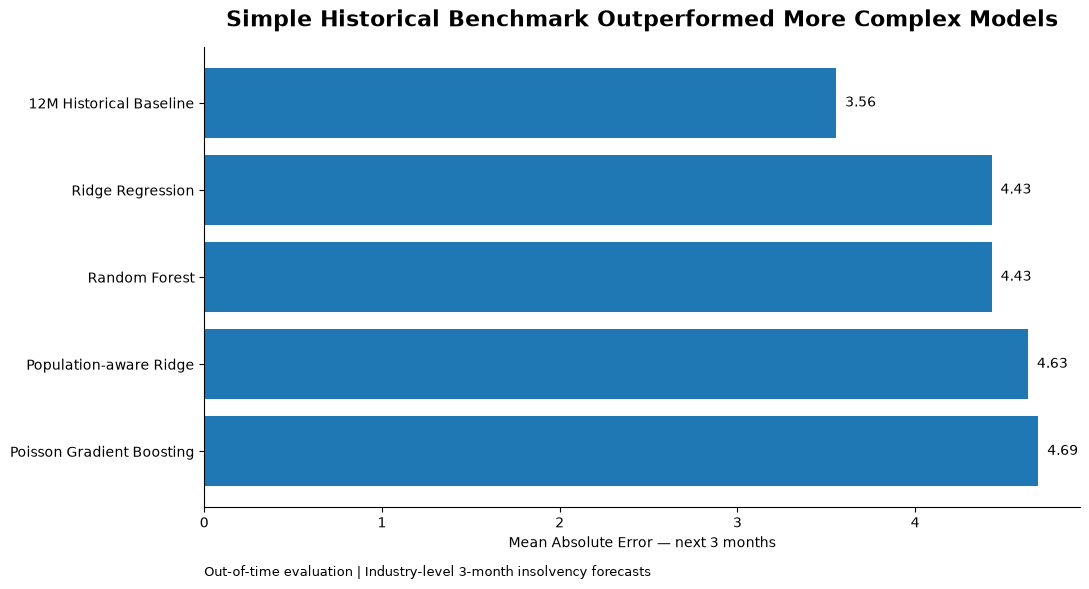

In [186]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

model_results = pd.DataFrame({
    "Model": [
        "12M Historical Baseline",
        "Ridge Regression",
        "Random Forest",
        "Poisson Gradient Boosting",
        "Population-aware Ridge"
    ],
    "Test MAE": [
        3.556,
        4.430,
        4.431,
        4.693,
        4.635
    ],
    "Test RMSE": [
        8.617,
        10.428,
        11.069,
        13.601,
        10.810
    ]
})

model_results = model_results.sort_values("Test MAE")

fig, ax = plt.subplots(figsize=(11, 6))

bars = ax.barh(
    model_results["Model"],
    model_results["Test MAE"]
)

ax.invert_yaxis()

ax.set_title(
    "Simple Historical Benchmark Outperformed More Complex Models",
    fontsize=16,
    fontweight="bold",
    pad=15
)

ax.set_xlabel("Mean Absolute Error — next 3 months")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

for bar, value in zip(bars, model_results["Test MAE"]):
    ax.text(
        value + 0.05,
        bar.get_y() + bar.get_height()/2,
        f"{value:.2f}",
        va="center",
        fontsize=10
    )

ax.text(
    0,
    -0.15,
    "Out-of-time evaluation | Industry-level 3-month insolvency forecasts",
    transform=ax.transAxes,
    fontsize=9
)

plt.tight_layout()
plt.show()

In [188]:
view_columns = pd.read_sql("""
    SHOW COLUMNS FROM vw_industry_trends
""", engine)

view_columns

,Field,Type,Null,Key,Default,Extra
0,month_date,date,NO,,NaN,
1,sic07_3_digit,varchar(3),NO,,NaN,
2,industry_description,varchar(255),NO,,NaN,
3,insolvencies,bigint,NO,,0,
4,insolvencies_12m_ago,bigint,YES,,NaN,
5,yoy_change_pct,"decimal(26,1)",YES,,NaN,
6,rolling_12m_insolvencies,"decimal(42,0)",YES,,NaN,
7,previous_12m_insolvencies,"decimal(42,0)",YES,,NaN,
8,rolling_12m_change_pct,"decimal(48,1)",YES,,NaN,


In [189]:
industry_pressure = pd.read_sql("""
    SELECT
        sic07_3_digit,
        industry_description,
        rolling_12m_insolvencies,
        previous_12m_insolvencies,
        rolling_12m_change_pct
    FROM vw_industry_trends
    WHERE month_date = '2026-08-01'
      AND rolling_12m_insolvencies IS NOT NULL
      AND previous_12m_insolvencies IS NOT NULL
    ORDER BY rolling_12m_insolvencies DESC
    LIMIT 10
""", engine)

industry_pressure

,sic07_3_digit,industry_description,rolling_12m_insolvencies,previous_12m_insolvencies,rolling_12m_change_pct
0,561,Restaurants and mobile food service activities,2082.0,2147.0,-3.0
1,829,Business support service activities n.e.c,928.0,1135.0,-18.2
2,960,Other personal service activities,904.0,1011.0,-10.6
3,620,"Computer programming, consultancy and related activities",852.0,890.0,-4.3
4,432,"Electrical, plumbing and other construction installation activities",847.0,871.0,-2.8
5,412,Construction of residential and non-residential buildings,836.0,812.0,3.0
6,411,Development of building projects,717.0,688.0,4.2
7,563,Beverage serving activities,674.0,722.0,-6.6
8,433,Building completion and finishing,654.0,753.0,-13.1
9,702,Management consultancy activities,627.0,657.0,-4.6


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

plot_df = industry_pressure.copy()

# Shorter labels for a clean business chart
plot_df["label"] = [
    "Restaurants & mobile food",
    "Business support services",
    "Other personal services",
    "Computer programming",
    "Construction installation",
    "Building construction",
    "Property development",
    "Beverage serving",
    "Building completion",
    "Management consultancy"
]

# Reverse so the largest bar appears at the top of the chart
plot_df = plot_df.iloc[::-1].reset_index(drop=True)

fig, ax = plt.subplots(figsize=(11, 6.5))

bars = ax.barh(
    plot_df["label"],
    plot_df["rolling_12m"],
    color="#2b6cb0"
)

for bar, (_, row) in zip(bars, plot_df.iterrows()):
    arrow = "\u25b2" if row["change_pct"] > 0 else "\u25bc"
    ax.text(
        bar.get_width() + 15,
        bar.get_y() + bar.get_height() / 2,
        f"{int(row['rolling_12m']):,}  {arrow} {abs(row['change_pct']):.1f}%",
        va="center",
        fontsize=9
    )

ax.set_title("High-Volume Industries Show Diverging Insolvency Pressure", fontsize=14, weight="bold")
ax.set_xlabel("Company insolvencies \u2014 latest rolling 12 months")
ax.set_title(
    "Top 10 industries by insolvency volume, Sep 2025\u2013Aug 2026",
    fontsize=10, loc="left", color="#555555"
)
fig.text(
    0.01, -0.02,
    "Change compares Sep 2025\u2013Aug 2026 with the preceding 12 months.\n"
    "Source: UK Insolvency Service record-level company insolvency data. Excludes bulk cases and Table 1b excluded case types.",
    fontsize=7.5, color="#666666"
)

plt.tight_layout()
plt.savefig("../reports/figures/top10_industry_volume.png", dpi=150, bbox_inches="tight")
plt.show()


## Business Conclusions

This project analysed more than 220,000 company insolvency records from the
UK Insolvency Service covering January 2016 to August 2026, with industry
business-population data from the ONS used to provide additional context.

### 1. Insolvency pressure remains substantial, but the recent direction is downward

England and Wales recorded 1,857 company insolvencies in August 2026 under
the non-seasonally-adjusted analytical definition used in this project.

The rolling 12-month total declined from 23,883 in August 2025 to 22,960 in
August 2026, indicating that overall insolvency volume remained elevated but
had eased compared with the previous year.

### 2. Insolvency pressure is highly concentrated by industry

Restaurants and mobile food service activities recorded 2,082 insolvencies
during Sep 2025–Aug 2026, the largest rolling 12-month total among 3-digit
SIC industries.

However, high volume did not necessarily indicate deterioration. Restaurant
insolvencies were 3.0% lower than in the preceding 12 months, while business
support services fell 18.2% and other personal services fell 10.6%.

### 3. Some construction-related industries moved against the broader pattern

Among the ten highest-volume industries, construction of buildings increased
3.0% and development of building projects increased 4.2% compared with the
preceding 12 months.

This demonstrates why monitoring both the level and direction of insolvency
pressure provides more useful information than ranking industries by raw
counts alone.

### 4. Adjusting for industry size changes the interpretation

ONS enterprise-population data showed that industries with the largest
numbers of insolvencies were not always those with the highest insolvency
incidence per 10,000 enterprises.

This distinction is important for business monitoring: raw counts measure the
scale of distress, while population-adjusted incidence provides context on how
unusual that distress is relative to industry size.

The incidence measure in this project should be interpreted as a comparative
proxy because the insolvency numerator covers England and Wales while the
available ONS enterprise denominator is UK-wide.

### 5. Simple forecasting proved difficult to beat

For forecasting industry insolvencies over the following three months, a
simple trailing 12-month benchmark achieved a test MAE of 3.56 and RMSE of
8.62.

Ridge regression, Random Forest and Poisson Gradient Boosting did not improve
on this benchmark.

A separate population-aware Ridge experiment also underperformed its
like-for-like benchmark (test MAE 4.64 versus 3.65).

The results show that greater model complexity does not automatically produce
better forecasts and reinforce the importance of benchmarking models against
simple, interpretable alternatives.

### 6. Sudden sector-specific shocks remain a major forecasting limitation

Error analysis identified SIC 681 (buying and selling of own real estate) as
an unusually concentrated episode. Such abrupt changes were difficult to
anticipate using historical insolvency patterns alone.

This suggests that the monitoring framework is strongest as an industry
distress surveillance tool, while sudden external or company-specific events
remain difficult to predict from insolvency history alone.

## Business Value

The final pipeline provides a reproducible framework for:

- monitoring changes in company insolvency pressure;
- identifying industries with high or accelerating distress;
- separating absolute insolvency volume from population-adjusted incidence;
- detecting unusual sector-level patterns;
- benchmarking short-term forecasts; and
- supporting evidence-based industry risk monitoring.

Rather than treating machine learning as the objective, the project uses
Python, SQL and statistical modelling to answer a practical business question:
where is corporate financial stress concentrated, how is it changing, and
how reliably can recent patterns inform the near future?

## 7. Final validation: sanity-checking the headline R²

A pooled R² of 0.973 sounds almost too good, and that's worth being suspicious of rather than proud of. This section checks whether that score is doing genuine work, or is mostly explained by industries simply differing in scale, and looks at error industry-by-industry rather than pooled.


In [193]:
# FINAL SANITY CHECK — HIGH R²

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

# Recreate the exact original modelling splits
check_train = model_data[
    model_data["month_date"] < "2023-01-01"
].copy()

check_test = model_data[
    model_data["month_date"] >= "2025-01-01"
].copy()

# 1. Winning 12-month baseline
check_test["pred_12m_baseline"] = (
    check_test["previous_12m_total"] / 4
)

# 2. Simple 3-month persistence
check_test["pred_3m_persistence"] = (
    check_test["previous_3m_total"]
)

# 3. Historical industry average
# Calculated ONLY from training period
industry_train_mean = (
    check_train
    .groupby("sic07_3_digit")[target_col]
    .mean()
)

check_test["pred_industry_mean"] = (
    check_test["sic07_3_digit"]
    .map(industry_train_mean)
)


def sanity_metrics(data, prediction_col):
    mask = (
        data[target_col].notna()
        & data[prediction_col].notna()
    )

    actual = data.loc[mask, target_col]
    pred = data.loc[mask, prediction_col]

    return {
        "N": len(actual),
        "MAE": mean_absolute_error(actual, pred),
        "RMSE": np.sqrt(mean_squared_error(actual, pred)),
        "R²": r2_score(actual, pred)
    }


results = pd.DataFrame({
    "12M historical baseline":
        sanity_metrics(check_test, "pred_12m_baseline"),

    "3M persistence":
        sanity_metrics(check_test, "pred_3m_persistence"),

    "Training-period industry mean":
        sanity_metrics(check_test, "pred_industry_mean")
}).T

display(results.round(3))

,N,MAE,RMSE,R²
12M historical baseline,4624.0,3.556,8.617,0.973
3M persistence,4624.0,4.543,10.733,0.957
Training-period industry mean,4624.0,7.431,20.486,0.845


In [194]:
# Per-industry forecasting performance

industry_performance = (
    check_test
    .assign(
        absolute_error=lambda x:
            abs(x[target_col] - x["pred_12m_baseline"])
    )
    .groupby(["sic07_3_digit", "industry_description"])
    .agg(
        observations=(target_col, "size"),
        mean_actual=(target_col, "mean"),
        MAE=("absolute_error", "mean")
    )
    .reset_index()
)

print("Industries:", len(industry_performance))
print()
print("Median industry MAE:",
      round(industry_performance["MAE"].median(), 3))
print("25th percentile:",
      round(industry_performance["MAE"].quantile(0.25), 3))
print("75th percentile:",
      round(industry_performance["MAE"].quantile(0.75), 3))
print("90th percentile:",
      round(industry_performance["MAE"].quantile(0.90), 3))

display(
    industry_performance
    .sort_values("MAE", ascending=False)
    .head(10)
)

Industries: 272

Median industry MAE: 1.728
25th percentile: 0.809
75th percentile: 3.647
90th percentile: 7.81


,sic07_3_digit,industry_description,observations,mean_actual,MAE
202,681,Buying and selling of own real estate,17,108.000000,48.367647
238,829,Business support service activities n.e.c,17,259.176471,43.058824
176,561,Restaurants and mobile food service activities,17,529.470588,31.691176
267,960,Other personal service activities,17,239.764706,22.705882
133,432,"Electrical, plumbing and other construction installation activities",17,216.117647,20.088235
189,620,"Computer programming, consultancy and related activities",17,220.470588,19.808824
178,563,Beverage serving activities,17,180.117647,19.779412
127,411,Development of building projects,17,181.647059,17.514706
218,749,"Other professional, scientific and technical activities n.e.c",17,64.823529,17.352941
160,494,Freight transport by road and removal services,17,99.352941,15.955882


The pooled R² of 0.973 is partly driven by persistent differences in insolvency scale across industries. I checked this explicitly: even a training-period industry-mean benchmark achieved R² of 0.845. However, the rolling 12-month benchmark materially improved MAE from 7.43 to 3.56 and RMSE from 20.49 to 8.62. I also evaluated errors at industry level; median MAE was 1.73, while a small number of high-volume or shock-affected industries accounted for much larger errors. So I don’t interpret R² as 97% forecasting accuracy.”